# PROJEKT KONCOWY

In [2]:
# data manipulation
import numpy as np
import pandas as pd
import datetime as dt
import time
from math import sqrt
from tqdm import tqdm


# data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# feature selection
from sklearn.feature_selection import RFECV

# pipeline
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

# models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# optimization and hyperparameters
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# model evaluation
from sklearn.metrics import mean_squared_error
from sklearn.metrics import make_scorer

# interpretowalność modelu
#import shap
#shap.initjs()

# zapisanie modelu
import joblib

# settings
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

# 1. zrozumienie uwarunkowan biznesowych

Innymi słowy – zrozumienie problemu! Możemy przecież wykorzystywać analizę danych i techniki uczenia maszynowego w różnych dziedzinach – geodezji, farmacji, ekonomii itd. W tej części musimy się dowiedzieć – na jakie pytanie ma nam odpowiadać model, jak obecnie jest rozwiązywany problem, jakie informacje wykorzystują specjaliści z tego zakresu oraz czy jest możliwe zastosowanie uczenia maszynowego w tym konkretnym przypadku. Przejdźmy do naszego problemu, który mamy do rozwiązania!

Załóżmy, że pracujemy w dziale badań i rozwoju firmy wypożyczającej rowery. Obecnie firma przygotowuje na swoich stanowiskach tyle rowerów, jaka była średnia z wypożyczonych jednośladów w poprzednim tygodniu oraz w poprzednim roku.

Niewystarczająca liczba rowerów na stanowiskach to utracony zysk o wartości 10zł, taki bowiem jest średni zysk z wypożyczenia jednego roweru na tej trasie.

Jeśli zbyt wiele rowerów jest na stanowisku, to utrzymujemy rowery, które nie przynoszą zysku, a wcześniej musieliśmy je przywieźć – średni dzienny koszt, który ponosimy przez niewypożyczenie roweru to 1zł.

Procesy logistyczne w nasze firmie działają z tygodniowym wyprzedzeniem. W związku z tym prognozę robimy na następny tydzień. To znaczy po skończonym poniedziałku (czyli wiemy ile wypożyczono rowerów tego dnia) robimy prognozę na poniedziałek w następnym tygodniu. To nic innego, jak uwarunkowania biznesowe.

## 2. Zrozumienie Danych

Ten etap często jest źle zrozumiany przez mniej doświadczonych badaczy, którzy sprawdzają rozkłady/korelacje i inne rzeczy, kopiują z kursów i nic za tym nie idzie. W tej części powinniśmy odpowiedzieć sobie na pytanie, które zmienne mają wpływ na naszą zmienną objaśnianą (y) oraz jakie kroki powinniśmy dalej wykonać:

- czy któraś zmienna jest wyciekiem danych i powinna być usunięta,
- czy są zmienne skorelowane ze sobą i przekazują tę samą informację,
- czy są braki w danych i JAK JE UZUPEŁNIĆ,
- czy są wartości odstające/nieprawdziwe i jak/czy powinniśmy je zamienić,
- jak przekształcić dane aby, model miał „łatwiej”.

Podsumowując – po tym kroku powinniśmy wiedzieć, co mamy robić w kolejnym kroku (Przygotowanie danych).

In [3]:
dataframe = pd.read_csv('bikerides_day.csv')
dataframe['Date'] = pd.to_datetime(dataframe['Date'])
dataframe

,Date,Volume,Rain,Temp
0,2016-11-17,933.0,9.0,2.1
1,2016-11-18,1197.0,6.7,3.9
2,2016-11-19,243.0,5.4,2.0
3,2016-11-20,234.0,3.9,2.8
4,2016-11-21,2148.0,7.3,2.8
...,...,...,...,...
1268,2020-05-16,2484.0,0.0,6.6
1269,2020-05-17,1509.0,0.0,9.1
1270,2020-05-18,5775.0,0.0,9.3
1271,2020-05-19,6741.0,0.0,9.7


Mamy dane czasowe o częstotliwości dziennej i dla każdego dnia mamy liczbę rowerzystów oraz dane pogodowe w tych dniach, którymi są opady oraz temperatura. Zakładamy, że w przyszłości pogoda zapowiada się idealnie. Teraz odpowiedzmy sobie na kilka pytań, które pomogą nam w przygotowaniu danych.

# Czy sa brakujace wartosci?

In [4]:
dataframe.isnull().mean()*100


Date      0.0
Volume    0.0
Rain      0.0
Temp      0.0
dtype: float64

Ten kod oblicza procent brakujących wartości (NaN) w każdej kolumnie DataFrame’u:
dataframe.isnull().mean() * 100

- isnull() – zamienia każdą wartość na True, jeśli jest brakiem (NaN), lub False
- mean() – liczy średnią w każdej kolumnie; True jest traktowane jako 1, a False jako 0
- * 100 – zamienia wynik na procent
 
  
Przykładowy wynik:
wiek        10.0
miasto      25.0
zarobki      0.0
Oznacza to, że w kolumnie wiek brakuje 10% wartości, w miasto 25%, a w zarobki nie ma braków.

Braków nie ma dla indeksów, jednak to nie znaczy, że braków nie ma gdzie indziej. Niejasne? Zaraz stanie się to jasne, takie sprawdzenie nie wystarczy.

# Czy są duplikaty dla daty?

In [5]:
dataframe.loc[dataframe.duplicated(subset='Date', keep=False), :]

,Date,Volume,Rain,Temp


Ten kod wybiera z DataFrame’u wszystkie wiersze, w których wartość kolumny Date występuje więcej niż raz:
dataframe.loc[
    dataframe.duplicated(subset='Date', keep=False),
    :
]
duplicated(subset='Date') – sprawdza duplikaty wyłącznie w kolumnie Date
keep=False – oznacza jako True wszystkie wystąpienia powtarzającej się daty, również pierwsze
.loc[warunek, :] – zwraca wiersze spełniające warunek oraz wszystkie kolumny (:)
Przykład:
Date        Value
2024-01-01  10
2024-01-02  20
2024-01-01  30
Wynik:
Date        Value
2024-01-01  10
2024-01-01  30
Kod jedynie wyświetla duplikaty — nie usuwa ich.

# CZy daty sa posortowane ?

In [6]:
(dataframe['Date'] == dataframe['Date'].sort_values()).all()

np.True_

# Czy Sa wszystkie daty ?

To, że w naszym zbiorze nie ma braków to nie znaczy, że one nie istnieją. Jako że mamy dane czasowe o częstotliwości dziennej, to brakiem będzie brak któregokolwiek dnia z zakresu od najstarszej do najnowszej. Tak, w tym przypadku to będzie brak. Zadaj sobie pytanie, czy wiesz, aby jak to sprawdzić.

By to zrobić, tworzymy zakres wszystkich dat, które powinny się pojawić w zbiorze. Wykorzystujemy funkcję date_range z biblioteki Pandas, podajemy minimalną datę i maksymalną dla niej. Następnie wykorzystujemy metodę difference, aby wskazać, jakich dat brakuje w zbiorze danych.

In [7]:
pd.date_range(start=dataframe['Date'].min(), end=dataframe['Date'].max()).difference(dataframe['Date'])

DatetimeIndex(['2017-10-16', '2019-01-14', '2019-06-07', '2019-06-08',
               '2019-06-09', '2019-06-10', '2019-08-14', '2019-08-15'],
              dtype='datetime64[ns]', freq=None)

Jednak, są brakujące wartości. Sprawdźmy czy jest tak na pewno, spróbujmy wyświetlić pierwszą brakującą wartość.

In [8]:
dataframe.loc[dataframe['Date']=='2017-10-16',:]

,Date,Volume,Rain,Temp


Brak wartości. Sprawdźmy czy wartość jest dla dnia poprzedzającego.

In [9]:
dataframe.loc[dataframe['Date']=='2017-10-15',:]

,Date,Volume,Rain,Temp
332,2017-10-15,843.0,0.0,9.6


To jest właśnie CEL eksploracyjnej analizy danych, znaleźliśmy problem w danych surowych. Wiemy, że mamy brakujące daty, powinniśmy je uzupełnić – szczególnie w zbiorze treningowym, niekoniecznie w zbiorze testowym, ponieważ w tym przypadku będziemy uzupełniać y. Czy wartość średnia lub mediana będzie odpowiednia, aby uzupełnić zmienną objaśnianą y? Spróbuj odpowiedzieć sobie na to pytanie.

najrozsądniej byłoby:
Uzupełnić indeks brakującymi datami, aby zachować ciągłość kalendarza.
Pozostawić dla nich y = NaN.
Nie wykorzystywać tych wierszy podczas uczenia i oceny modelu.
Nie usuwać dat całkowicie, jeżeli tworzysz cechy opóźnione (lag) lub średnie kroczące.
dataframe['Date'] = pd.to_datetime(dataframe['Date'])
dataframe = dataframe.set_index('Date').asfreq('D')

training_data = dataframe.dropna(subset=['y'])
Jeżeli jednak zadanie wymaga uzupełnienia y, nie stosowałbym globalnej średniej ani mediany. Lepszym przybliżeniem byłaby mediana dla podobnych dni — np. tego samego miesiąca i dnia tygodnia:


dataframe['month'] = dataframe.index.month
dataframe['weekday'] = dataframe.index.dayofweek

seasonal_median = dataframe.groupby(
    ['month', 'weekday']
)['y'].transform('median')

dataframe['y_imputed'] = dataframe['y'].fillna(seasonal_median)


Trzeba pamiętać, że cztery dni od 7 do 10 czerwca obejmują piątek–poniedziałek, więc zastąpienie ich jedną średnią byłoby szczególnie nietrafione — weekendowe wypożyczenia mogą zachowywać się inaczej niż te w dni robocze.
Do projektu możesz wpisać:
Brakujące daty stanowią około 0,63% obserwacji. Nie są jednak całkowicie losowo rozproszone, ponieważ cztery kolejne braki występują między 7 a 10 czerwca 2019 roku. Uzupełnienie zmiennej objaśnianej globalną średnią lub medianą mogłoby zaburzyć sezonowość oraz różnice między dniami roboczymi i weekendami. Dlatego brakujące daty zostały dodane do osi czasu, ale obserwacje bez znanej wartości y pominięto podczas treningu. Gdyby imputacja była konieczna, należałoby zastosować metodę uwzględniającą co najmniej miesiąc i dzień tygodnia.



14:29

# Jaki jest rozkład naszych danych?

In [10]:
dataframe.describe()

,Date,Volume,Rain,Temp
count,1273,1273.000000,1273.000000,1273.000000
mean,2018-08-17 15:16:15.648075264,2609.344855,1.945640,6.783975
min,2016-11-17 00:00:00,63.000000,0.000000,-11.400000
25%,2017-10-01 00:00:00,1185.000000,0.000000,0.700000
50%,2018-08-16 00:00:00,2073.000000,0.000000,5.500000
75%,2019-07-05 00:00:00,3801.000000,1.400000,13.400000
max,2020-05-20 00:00:00,8679.000000,39.500000,25.900000
std,NaN,1968.623825,4.505151,7.726084


Aby rozszerzyć tę analizę, dodajmy histogramy oraz wykresy pudełkowe dla zmiennych numerycznych (czyli dla wszystkich poza datą).

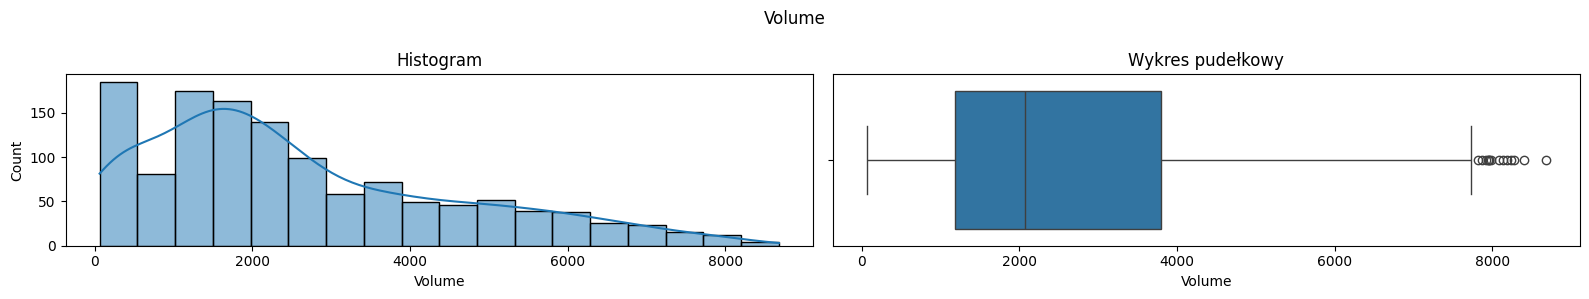

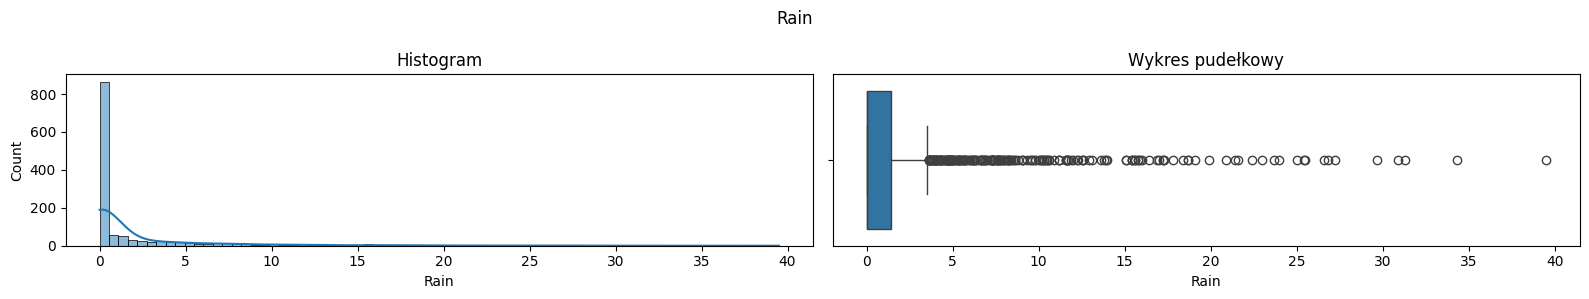

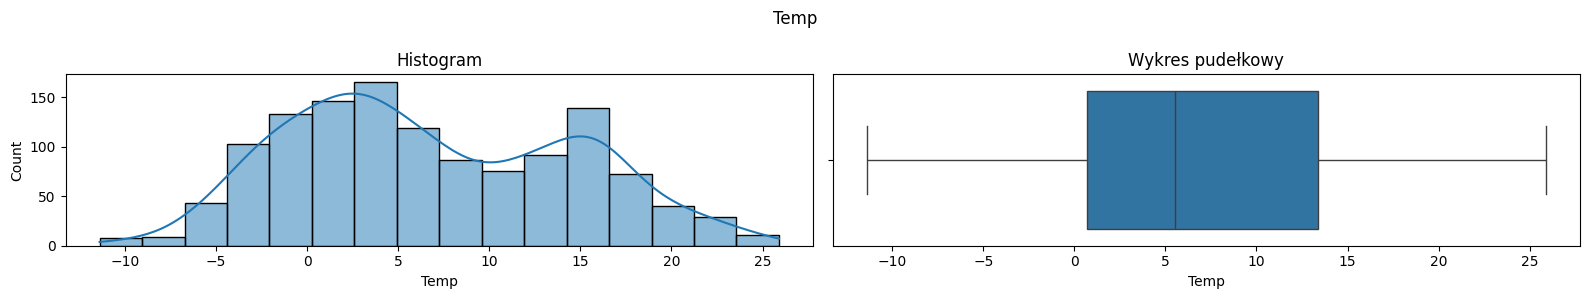

In [11]:
for variable in dataframe.select_dtypes(include=np.number).columns:  # Iteracja po kolumnach numerycznych
    fig, axes = plt.subplots(1, 2, figsize=(16, 3))                   # Utworzenie dwóch wykresów obok siebie
    fig.suptitle(variable, fontsize=12)                              # Ustawienie nazwy analizowanej kolumny

    sns.histplot(                                                     # Utworzenie histogramu
        data=dataframe,
        x=variable,
        kde=True,
        ax=axes[0]
    )
    axes[0].set_title('Histogram')                                   # Nadanie tytułu histogramowi

    sns.boxplot(                                                      # Utworzenie wykresu pudełkowego
        data=dataframe,
        x=variable,
        ax=axes[1]
    )
    axes[1].set_title('Wykres pudełkowy')                            # Nadanie tytułu wykresowi pudełkowemu

    plt.tight_layout()                                               # Dopasowanie odstępów między elementami
    plt.show()                                                       # Wyświetlenie wykresów

Nasza zmienna objaśniana y nie ma rozkładu normalnego.

To znaczy, że wartości zmiennej y — liczby dziennych wypożyczeń rowerów — nie układają się zgodnie z rozkładem normalnym, czyli symetryczną krzywą w kształcie dzwonu.
W rozkładzie normalnym:
- większość obserwacji znajduje się w pobliżu średniej,
- małe i duże wartości występują coraz rzadziej,
- rozkład jest symetryczny,
- średnia i mediana są do siebie zbliżone.
- 
W Twoich danych rozkład może być na przykład skośny, mieć kilka szczytów albo zawierać dużo wartości skrajnych. Jest to całkiem logiczne dla wypożyczeń rowerów, ponieważ ich liczba zależy m.in. od sezonu, pogody, weekendów i trendu w czasie.
Nie oznacza to automatycznie problemu. W regresji liniowej zmienna y sama w sobie nie musi mieć rozkładu normalnego. Założenie normalności, jeśli jest potrzebne do wnioskowania statystycznego, dotyczy przede wszystkim reszt modelu, czyli różnic:

Zmienna objaśniana nie ma rozkładu normalnego, co może wynikać z sezonowości, trendu oraz wpływu warunków pogodowych i kalendarzowych. Nie jest to samo w sobie przeszkodą w modelowaniu regresyjnym, ponieważ normalność zmiennej objaśnianej nie jest ogólnym wymaganiem modeli regresji. W przypadku regresji liniowej należy przeanalizować przede wszystkim rozkład reszt modelu.



14:46

Wracając do naszej zmiennej liczby wypożyczonych rowerów, czy jest to problem? Jeśli stosujemy modele parametryczne (czyli regresja liniowa, SVM, sieć neuronowa), to lubią one zmienne z rozkładu normalnego. Aby doprowadzić taką zmienną do rozkładu gaussowskiego, warto na przykład zlogarytmować tę zmienną, możesz zastosować PoweTransformer z biblioteki skcikit-learn.

Dla deszczu widzimy, że jest sporo wartości odstających, a to dlatego, że zazwyczaj nie ma opadów.

Co do temperatury to widać, że jest ona najczęściej w okolicach 7°C lub 15°C.

Teraz czas sprawdzić jak liczba wypożyczonych rowerów jest wyjaśniona przez samą siebie w czasie (sezonowość, trend) oraz jak zależy od zewnętrznych zmiennych, takich jak opady deszczu czy temperatura.

# Jak wygląda liczba wypożyczonych rowerów w czasie?

Zróbmy wizualizację liczby wypożyczonych rowerów względem poszczególnych dni. Spodziewać się możemy pewnej sezonowości tygodniowej (w jeden dzień tygodnia jest średnio więcej wypożyczeń niż w inny), zatem dodajmy średnią kroczącą siedmiodniową

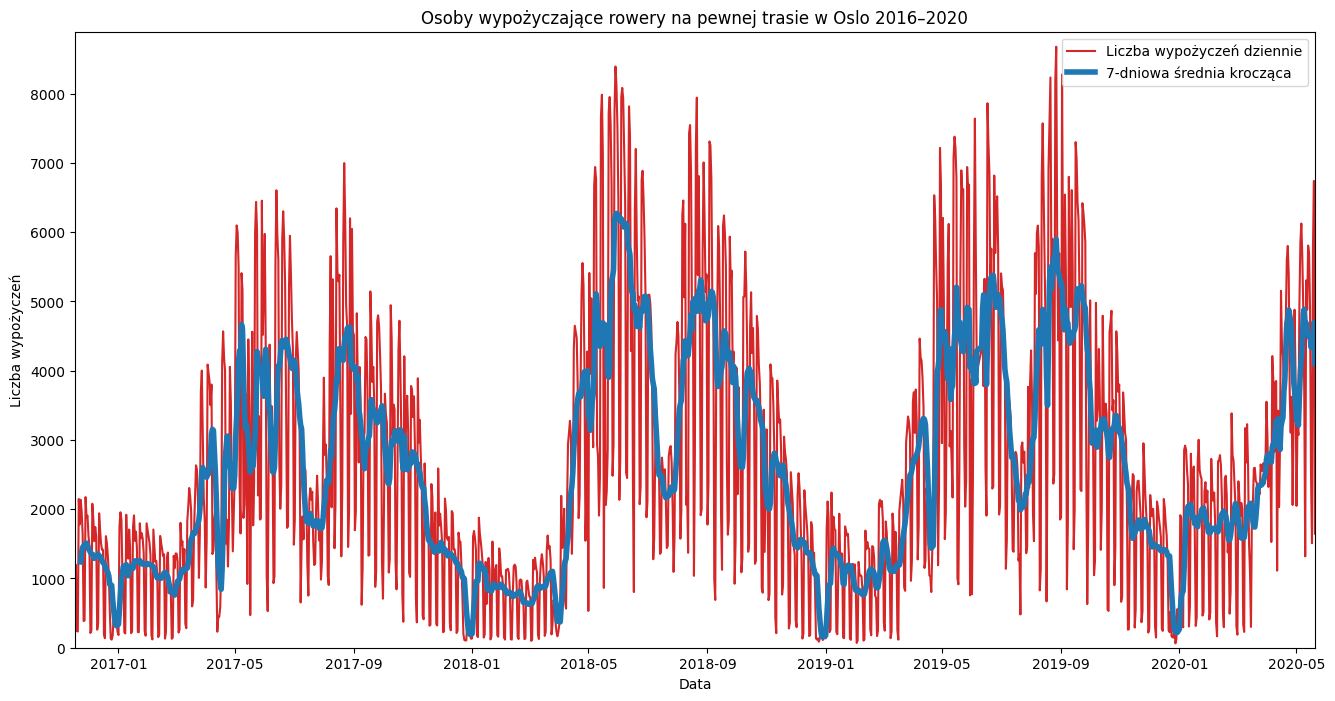

In [12]:
plt.figure(figsize=(16, 8), dpi=100)                              # Utworzenie wykresu o wymiarach 16 × 8 cali i rozdzielczości 100 DPI
plt.plot(dataframe['Date'], dataframe['Volume'],                  # Narysowanie dziennej liczby wypożyczeń w czasie
         color='tab:red', label='Liczba wypożyczeń dziennie')     # Ustawienie koloru linii oraz opisu w legendzie
plt.plot(dataframe['Date'], dataframe['Volume'].rolling(7).mean(), # Narysowanie 7-dniowej średniej kroczącej
         color='tab:blue', linewidth=4,                            # Ustawienie koloru i grubości linii
         label='7-dniowa średnia krocząca')                        # Ustawienie opisu linii w legendzie
plt.title('Osoby wypożyczające rowery na pewnej trasie w Oslo 2016–2020')  # Nadanie tytułu wykresowi
plt.xlabel('Data')                                                 # Nadanie etykiety osi poziomej
plt.ylabel('Liczba wypożyczeń')                                    # Nadanie etykiety osi pionowej
plt.xlim([dataframe['Date'].min(), dataframe['Date'].max()])       # Ustawienie zakresu osi X na cały okres danych
plt.ylim([0, dataframe['Volume'].max() * 1.025])                   # Ustawienie zakresu osi Y z niewielkim zapasem nad maksimum
plt.legend(loc='upper right')                                      # Wyświetlenie legendy w prawym górnym rogu
plt.show()                                                         # Wyświetlenie gotowego wykresu

Widać sporą wariancję liczby wypożyczonych rowerów, co zapewne jest powodem sezonowości tygodniowej. Gdybyśmy policzyli wszystkie ‘górki’ w danym roku, to otrzymalibyśmy liczbę tygodni w roku. Ponadto widać też pewną sezonowość roczną (warto tutaj patrzeć na średnią kroczącą), wartość wypożyczonych rowerów wzrasta do wakacji, aby potem spaść i ponownie wzrosnąć. Nie musimy patrzeć na temperaturę, aby domyślać się, że zimą będzie mniej wypożyczonych rowerów, niż w miesiące ciepłe.

Aby zweryfikować domysły co do sezonowości, sprawdzić trend, stwórzmy kopię ramki danych dla pełnych lat. Nie bierzemy zatem roku 2016 oraz 2020, ponieważ tutaj nie mamy danych dla całego roku. Dodajemy do obserwacji informację, jaki to rok, miesiąc i dzień tygodnia.

In [13]:
full_years = dataframe.loc[                                      # Wybranie danych z pełnych lat 2017–2019
    (dataframe['Date'] >= '2017-01-01') &                        # Ustawienie początku analizowanego okresu
    (dataframe['Date'] < '2020-01-01')                           # Ustawienie końca okresu bez uwzględnienia 2020 roku
].copy()                                                         # Utworzenie niezależnej kopii wybranych danych

full_years['year'] = full_years['Date'].dt.year                  # Utworzenie kolumny zawierającej rok
full_years['month'] = full_years['Date'].dt.strftime('%b')       # Utworzenie kolumny z krótką nazwą miesiąca
full_years['weekday'] = full_years['Date'].dt.strftime('%A')     # Utworzenie kolumny z nazwą dnia tygodnia

full_years                                                        # Wyświetlenie przygotowanego DataFrame'u

,Date,Volume,Rain,Temp,year,month,weekday
45,2017-01-01,183.0,0.0,1.1,2017,Jan,Sunday
46,2017-01-02,1752.0,0.0,-2.8,2017,Jan,Monday
47,2017-01-03,1956.0,0.0,-2.5,2017,Jan,Tuesday
48,2017-01-04,1854.0,0.0,-3.1,2017,Jan,Wednesday
49,2017-01-05,1113.0,0.0,-10.1,2017,Jan,Thursday
...,...,...,...,...,...,...,...
1127,2019-12-27,342.0,0.0,-4.9,2019,Dec,Friday
1128,2019-12-28,63.0,0.0,-1.2,2019,Dec,Saturday
1129,2019-12-29,126.0,5.9,4.4,2019,Dec,Sunday
1130,2019-12-30,558.0,0.0,5.5,2019,Dec,Monday


Następnie zagregujmy zbiór danych do poziomu rok/miesiąc i jako funkcję agregującą wykorzystajmy średnią.

In [14]:
full_years_monthly = full_years.groupby(                         # Grupowanie danych według roku i miesiąca
    ['year', 'month']
)[['Volume']].mean()                                             # Obliczenie średniej dziennej liczby wypożyczeń w każdej grupie

full_years_monthly.reset_index(inplace=True)                     # Przeniesienie roku i miesiąca z indeksu do zwykłych kolumn

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",              # Zdefiniowanie miesięcy w kolejności kalendarzowej
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

full_years_monthly['month'] = pd.Categorical(                    # Zamiana kolumny month na uporządkowaną kategorię
    full_years_monthly['month'],
    categories=months,                                           # Określenie poprawnej kolejności miesięcy
    ordered=True
)

full_years_monthly.sort_values(                                  # Posortowanie danych chronologicznie
    by=['year', 'month'],
    inplace=True
)

display(full_years_monthly.head(3))                              # Wyświetlenie pierwszych trzech wierszy
display(full_years_monthly.tail(3))                              # Wyświetlenie ostatnich trzech wierszy

,year,month,Volume
4,2017,Jan,1202.225806
3,2017,Feb,980.250000
7,2017,Mar,1703.419355


,year,month,Volume
34,2019,Oct,3204.967742
33,2019,Nov,1852.500000
26,2019,Dec,1035.580645


Stworzyliśmy nowe zbiory danych, które pomogą nam w analizie danych pod względem sezonowości czy trendu. Najpierw skorzystajmy z drugiej ramki danych i zróbmy wykres liniowy średniej liczby wypożyczeń rowerów w zależności od miesiąca dla lat 2017, 2018 oraz 2019.

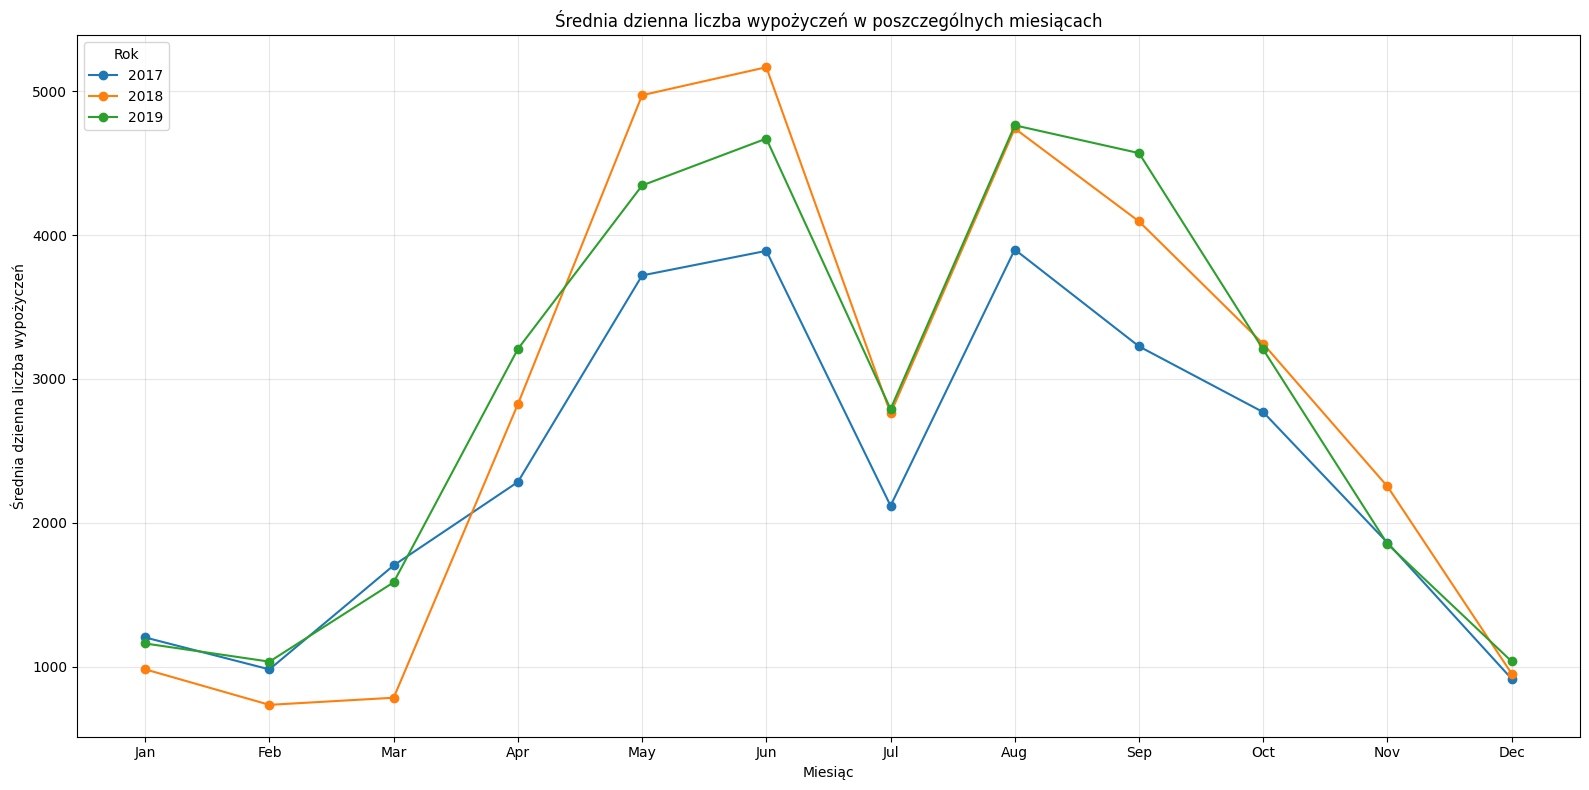

In [15]:
plt.figure(figsize=(16, 8), dpi=100)                                  # Utworzenie wykresu o wymiarach 16 × 8 cali

for year in full_years['year'].unique():                              # Iteracja po wszystkich analizowanych latach
    yearly_data = full_years_monthly.loc[                              # Wybranie danych miesięcznych dla danego roku
        full_years_monthly['year'] == year
    ]

    plt.plot(                                                          # Narysowanie średniej liczby wypożyczeń w kolejnych miesiącach
        yearly_data['month'],
        yearly_data['Volume'],
        marker='o',                                                    # Dodanie punktów odpowiadających poszczególnym miesiącom
        label=str(year)
    )

plt.title('Średnia dzienna liczba wypożyczeń w poszczególnych miesiącach')  # Nadanie tytułu wykresowi
plt.xlabel('Miesiąc')                                                  # Nadanie etykiety osi poziomej
plt.ylabel('Średnia dzienna liczba wypożyczeń')                        # Nadanie etykiety osi pionowej
plt.legend(title='Rok', loc='upper left')                              # Wyświetlenie legendy z oznaczeniami lat
plt.xticks(months)                                                     # Wyświetlenie wszystkich miesięcy w kolejności kalendarzowej
plt.grid(alpha=0.3)                                                    # Dodanie delikatnej siatki ułatwiającej odczyt wartości
plt.tight_layout()                                                     # Automatyczne dopasowanie elementów wykresu
plt.show()                                                             # Wyświetlenie gotowego wykresu

To, co najciekawsze, zależności są stałe dla lat. W miesiące zimne, takie jak grudzień, styczeń czy luty, widzimy najmniejszą średnią liczbę wypożyczonych rowerów. Inną ciekawą zależnością jest to, co widzieliśmy już wcześniej, dla lipca mamy znaczący spadek, być może ma to związek z tym, że mieszkańcy Oslo w tym czasie wyjeżdżają z miasta na upragnione wakacje. To co możesz też zauważyć dla 2017 roku – wartości są zazwyczaj niewiele niższe, co jest zauważalne.

Te zależności w inżynierii cech będziemy musieli przekazać modelowi, aby dane surowe zamienić w informacje, które model przekształci w mądrość.

To oczywiście nie koniec. Dokończmy proces sprawdzania sezonowości, do tego wykorzystamy wykresy pudełkowe:

- Rok (trend)
- Miesiąc (sezonowość)- 
- Dzień tygodnia (sezonowość)

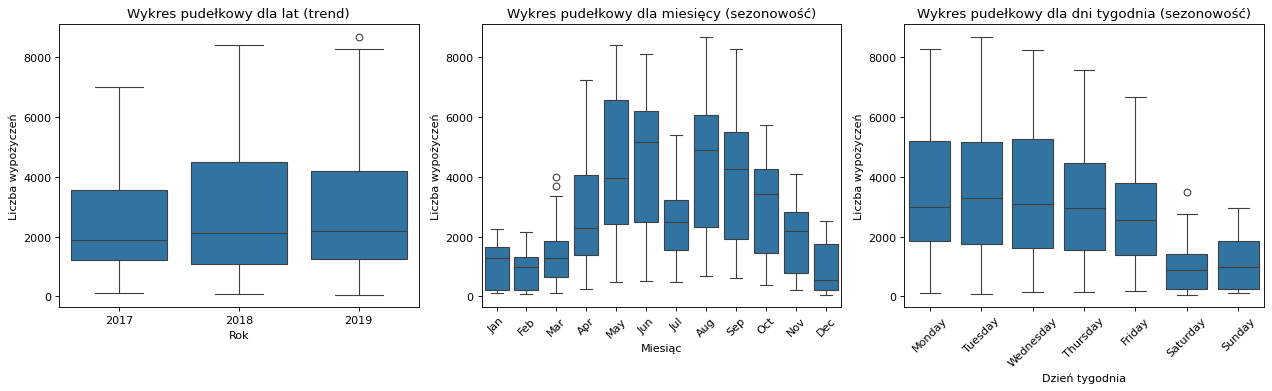

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=80)               # Utworzenie figury składającej się z trzech wykresów

sns.boxplot(                                                           # Utworzenie wykresu pudełkowego dla poszczególnych lat
    x='year',
    y='Volume',
    data=full_years,
    ax=axes[0]
)
axes[0].set(                                                           # Ustawienie opisów osi pierwszego wykresu
    xlabel='Rok',
    ylabel='Liczba wypożyczeń'
)
axes[0].set_title('Wykres pudełkowy dla lat (trend)')                  # Nadanie tytułu pierwszemu wykresowi

sns.boxplot(                                                           # Utworzenie wykresu pudełkowego dla poszczególnych miesięcy
    x='month',
    y='Volume',
    data=full_years,
    order=months,                                                      # Ustawienie miesięcy w kolejności kalendarzowej
    ax=axes[1]
)
axes[1].set(                                                           # Ustawienie opisów osi drugiego wykresu
    xlabel='Miesiąc',
    ylabel='Liczba wypożyczeń'
)
axes[1].set_title('Wykres pudełkowy dla miesięcy (sezonowość)')        # Nadanie tytułu drugiemu wykresowi
axes[1].tick_params(axis='x', rotation=45)                             # Obrócenie nazw miesięcy dla lepszej czytelności

weekdays = [                                                           # Zdefiniowanie dni tygodnia w odpowiedniej kolejności
    'Monday', 'Tuesday', 'Wednesday', 'Thursday',
    'Friday', 'Saturday', 'Sunday'
]

sns.boxplot(                                                           # Utworzenie wykresu pudełkowego dla dni tygodnia
    x='weekday',
    y='Volume',
    data=full_years,
    order=weekdays,                                                    # Ustawienie dni od poniedziałku do niedzieli
    ax=axes[2]
)
axes[2].set(                                                           # Ustawienie opisów osi trzeciego wykresu
    xlabel='Dzień tygodnia',
    ylabel='Liczba wypożyczeń'
)
axes[2].set_title('Wykres pudełkowy dla dni tygodnia (sezonowość)')    # Nadanie tytułu trzeciemu wykresowi
axes[2].tick_params(axis='x', rotation=45)                             # Obrócenie nazw dni tygodnia

plt.tight_layout()                                                     # Dopasowanie odstępów pomiędzy wykresami
plt.show()                                                             # Wyświetlenie gotowych wykresów

- Trend – nie widać, aby trend nadal obowiązywał, jednak liczba wypożyczonych rowerów dla 2017 roku była niższa. Może na przełomie 2017 i 2018 roku była akcja promocyjna, aby przestać korzystać z samochodu?
- Sezonowość roczna – ten temat już dobrze zbadaliśmy.
- Sezonowość tygodniowa – stąd wariancja. W dni robocze jest większa liczba wypożyczonych rowerów niż w weekend. Idąc dalej, widać różnice pomiędzy początkiem tygodnia (poniedziałek), a końcem tygodnia roboczego (piątek). Być może z powodu lenistwa część osób odpuszcza jazdę rowerem, a może wtedy pracownicy IT pracują zdalnie, a może jadą samochodem w piątek do pracy, aby po niej jak najszybciej wyjechać na weekend poza miasto, a może powód jest jeszcze inny. W tym przypadku powód nie jest najważniejszy, najważniejsza jest zależność, która jest znacząca i również warto to też zastosować podczas inżynierii cech.

Uff… Już rozumiemy, jak ma się liczba wypożyczonych rowerów w zależności od daty. Ale czy na pewno?

NIE! Poza typowymi dniami tygodnia może wystąpić święto i czasem co roku występuje w ten sam dzień tygodnia (np. Wielkanoc), jak i może wystąpić w różne dni (Święto Niepodległości, Boże Narodzenie).

Skorzystajmy z biblioteki holidays i dodajmy święta dla Norwegii. Ważne aby zauważyć, że niedziela („Søndag”) traktowana jest jako święto, nie bierzemy pod uwagę tego święta. Tworzymy funkcję get_holiday, którą aplikujemy do wcześniej stworzonej ramki danych full_years i dzięki niej otrzymujemy nową zmienną Holiday z wskazanym świętem (lub nie, jeśli nie było – większość okresu) dla konkretnej daty.

In [17]:
import holidays

In [18]:
holidays_Norway = holidays.NO()                                      # Utworzenie kalendarza norweskich świąt

def get_holiday(row):                                                # Zdefiniowanie funkcji przypisującej nazwę święta do daty
    holiday_name = holidays_Norway.get(row['Date'])                  # Pobranie nazwy święta przypadającego na daną datę

    if holiday_name is None:                                         # Sprawdzenie, czy dany dzień nie jest świętem
        return np.nan                                                 # Zwrócenie brakującej wartości dla zwykłego dnia

    if holiday_name == 'Søndag':                                     # Sprawdzenie, czy jedynym świętem jest niedziela
        return np.nan                                                 # Pominięcie niedzieli jako osobnego święta

    if 'Søndag' in holiday_name:                                     # Sprawdzenie, czy niedziela pokrywa się z innym świętem
        holiday_name = holiday_name.replace('Søndag', '')            # Usunięcie określenia „Søndag” z nazwy święta
        holiday_name = holiday_name.replace(',', '')                 # Usunięcie zbędnego przecinka
        holiday_name = holiday_name.strip()                           # Usunięcie zbędnych spacji

    return holiday_name                                               # Zwrócenie nazwy właściwego święta


full_years['Holiday'] = full_years.apply(                             # Utworzenie kolumny zawierającej nazwy świąt
    get_holiday,
    axis=1                                                            # Zastosowanie funkcji osobno do każdego wiersza
)

print('Unikalne święta:')                                            # Wyświetlenie nagłówka wyników
print(full_years['Holiday'].value_counts())                           # Wyświetlenie liczby wystąpień poszczególnych świąt

full_years                                                            # Wyświetlenie DataFrame’u z nową kolumną

Unikalne święta:
Holiday
Første nyttårsdag        3
Skjærtorsdag             3
Langfredag               3
Første påskedag          3
Andre påskedag           3
Arbeidernes dag          3
Grunnlovsdag             3
Kristi himmelfartsdag    3
Andre juledag            3
Første juledag           3
Andre pinsedag           2
Første pinsedag          2
Name: count, dtype: int64


,Date,Volume,Rain,Temp,year,month,weekday,Holiday
45,2017-01-01,183.0,0.0,1.1,2017,Jan,Sunday,Første nyttårsdag
46,2017-01-02,1752.0,0.0,-2.8,2017,Jan,Monday,NaN
47,2017-01-03,1956.0,0.0,-2.5,2017,Jan,Tuesday,NaN
48,2017-01-04,1854.0,0.0,-3.1,2017,Jan,Wednesday,NaN
49,2017-01-05,1113.0,0.0,-10.1,2017,Jan,Thursday,NaN
...,...,...,...,...,...,...,...,...
1127,2019-12-27,342.0,0.0,-4.9,2019,Dec,Friday,NaN
1128,2019-12-28,63.0,0.0,-1.2,2019,Dec,Saturday,NaN
1129,2019-12-29,126.0,5.9,4.4,2019,Dec,Sunday,NaN
1130,2019-12-30,558.0,0.0,5.5,2019,Dec,Monday,NaN


Być może nie znasz języka norweskiego, dlatego poniżej przygotowaliśmy dla Ciebie słownik świąt:

Første juledag - Pierwszy dzień Świąt Bożego Narodzenia
Andre juledag - Drugi dzień Świąt Bożego Narodzenia
Første nyttårsdag - Nowy Rok
Skjærtorsdag - Wielki Czwartek
Langfredag - Wielki Piątek
Første påskedag - Pierwszy dzień Wielkanocy
Andre påskedag - Drugi dzień Wielkanocy
Arbeidernes dag - Dzień Pracy
Grunnlovsdag - Dzień Konstytucji
Kristi himmelfartsdag - Dzień Wniebowstąpienia
Første pinsedag - Pierwszy dzień Zielonych Świąt
Andre pinsedag - Drugi dzień Zielonych Świąt

Mamy już święta, zatem chcielibyśmy sprawdzić ich wpływ na liczbę wypożyczonych rowerów. Jak to w analizie danych, jedną rzecz można sprawdzić na wiele sposobów. Wykorzystamy wykres pudełkowy dla zakresu miesiąca, w których święto wystąpiło z rozróżnieniem czy było to święto czy nie w danych miesiącach.

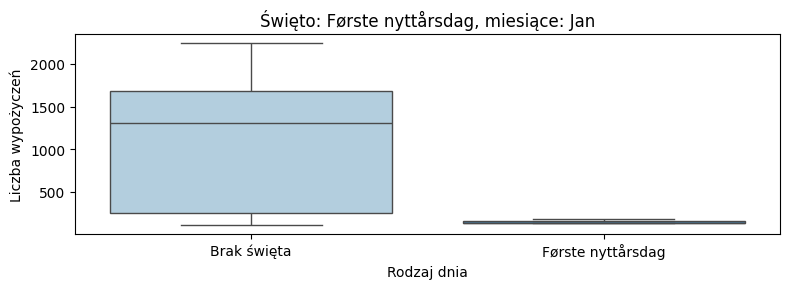

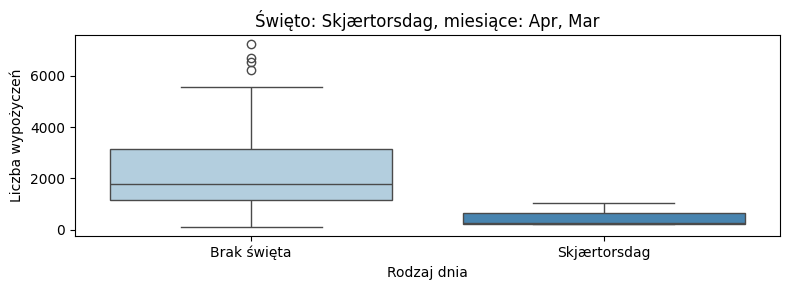

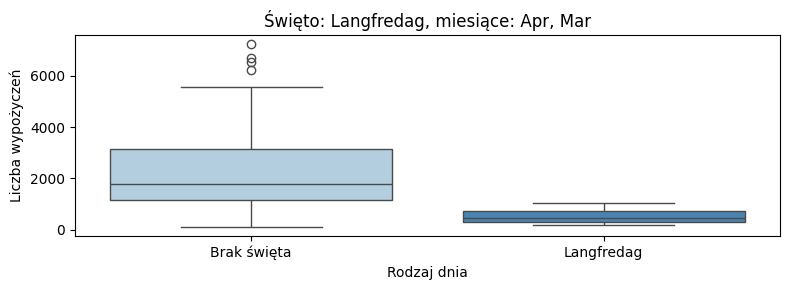

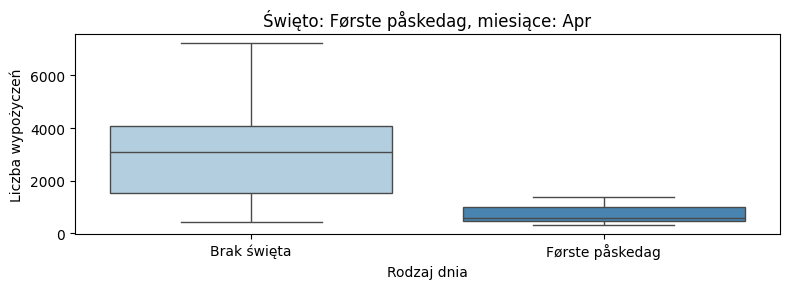

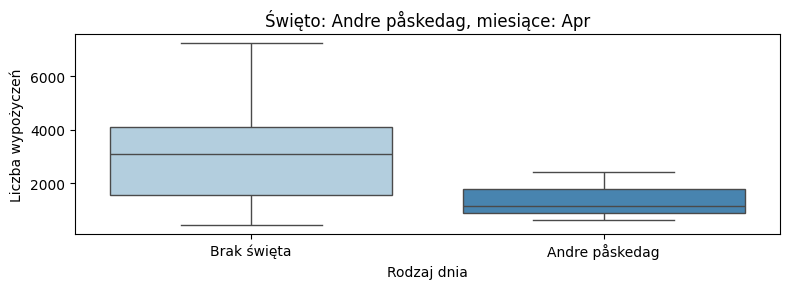

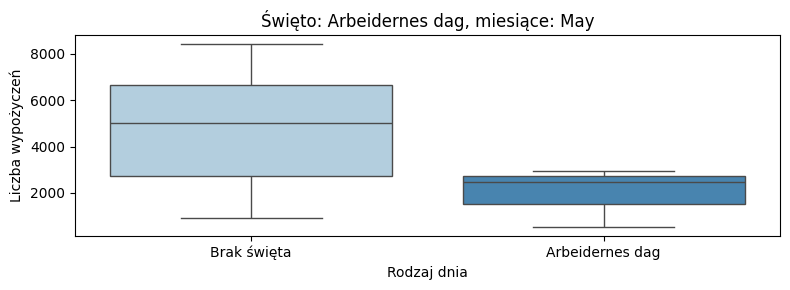

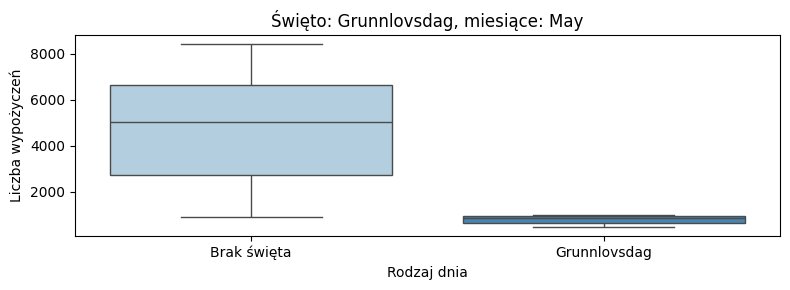

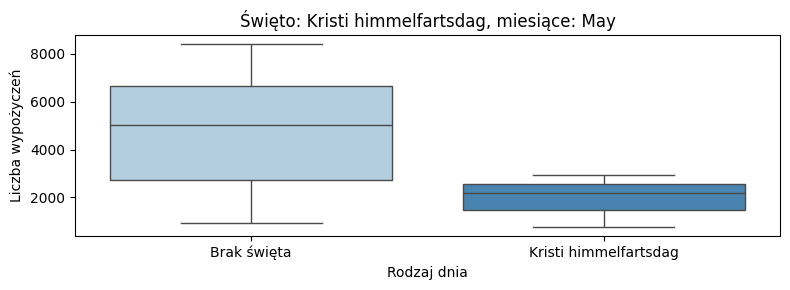

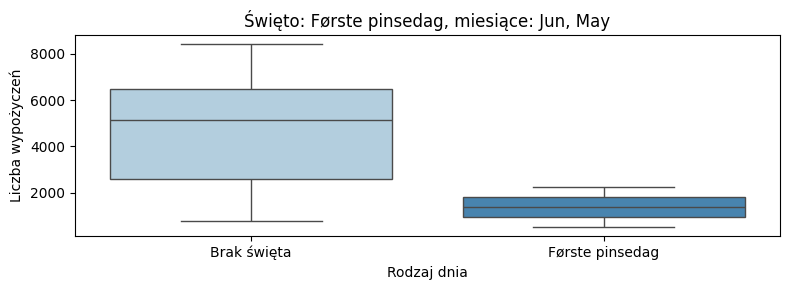

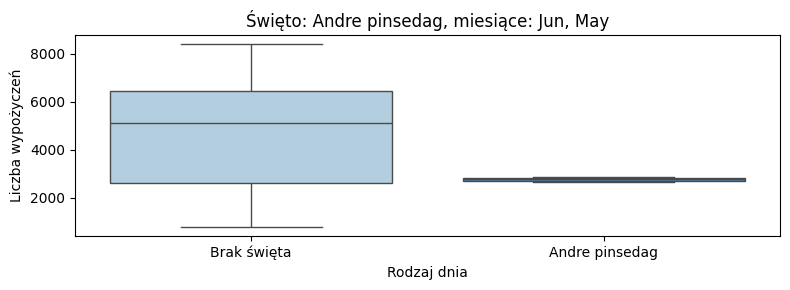

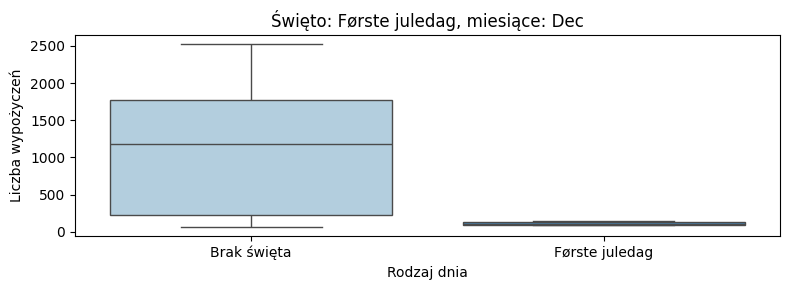

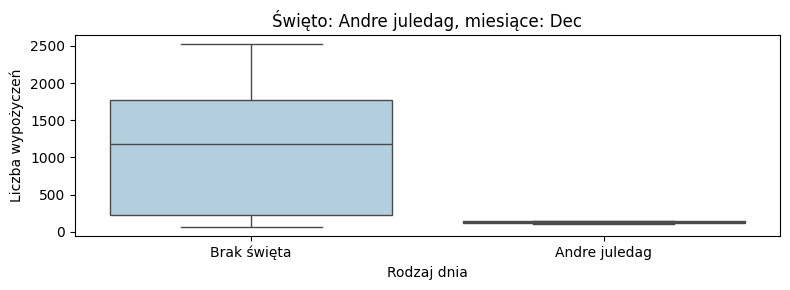

In [19]:
for unique_holiday in full_years['Holiday'].dropna().unique():             # Iteracja po wszystkich unikalnych świętach

    month_holiday = full_years.loc[                                         # Wybranie miesięcy, w których występuje dane święto
        full_years['Holiday'] == unique_holiday,
        'month'
    ].unique()

    selected_holiday = full_years.loc[                                     # Wybranie obserwacji z odpowiednich miesięcy
        full_years['month'].isin(month_holiday) &                           # Ograniczenie danych do miesięcy występowania święta
        (
            full_years['Holiday'].isna() |                                 # Uwzględnienie dni bez święta
            (full_years['Holiday'] == unique_holiday)                       # Uwzględnienie analizowanego święta
        )
    ].copy()

    selected_holiday['Holiday'] = selected_holiday['Holiday'].fillna(       # Zastąpienie brakujących wartości opisem
        'Brak święta'
    )

    holiday_order = ['Brak święta', unique_holiday]                         # Ustalenie kolejności kategorii na wykresie

    plt.figure(figsize=(8, 3))                                              # Utworzenie obszaru wykresu

    sns.boxplot(                                                             # Utworzenie wykresu pudełkowego
        data=selected_holiday,
        x='Holiday',
        y='Volume',
        hue='Holiday',                                                       # Ustawienie kategorii odpowiadającej kolorom
        order=holiday_order,
        hue_order=holiday_order,
        palette='Blues',
        legend=False                                                         # Ukrycie zbędnej legendy
    )

    months_text = ', '.join(map(str, month_holiday))                        # Połączenie nazw miesięcy w jeden napis
    plt.title(f'Święto: {unique_holiday}, miesiące: {months_text}')          # Nadanie tytułu wykresowi
    plt.xlabel('Rodzaj dnia')                                                # Nadanie etykiety osi poziomej
    plt.ylabel('Liczba wypożyczeń')                                          # Nadanie etykiety osi pionowej
    plt.tight_layout()                                                       # Dopasowanie elementów wykresu
    plt.show()                                                               # Wyświetlenie wykresu

Wszystkie święta są niczym weekendy, zauważalna jest zdecydowana mniejsza liczba wypożyczeń. Czy możemy stworzyć dla każdego święta One Hot Encoder? Niekoniecznie, święta są bardzo rzadkimi wydarzeniami, weźmy na przykład Wielkanoc – występuje jedynie raz w roku. Taka zmienna byłaby bardzo rzadka. Sprawdźmy wykres pudełkowy, gdybyśmy wszystkie święta połączyli w jedną wartość, czyli rozdzielili sytuacje – jest święto bądź go nie ma, nieważne jakie święto.

In [20]:
full_years['Holiday'] = (                                              # Przekształcenie nazw świąt na zmienną binarną
    full_years['Holiday']
    .notna()                                                           # Zwrócenie True dla święta i False dla zwykłego dnia
    .astype(int)                                                       # Zamiana True na 1, a False na 0
)

full_years                                                             # Wyświetlenie zmodyfikowanego DataFrame’u

,Date,Volume,Rain,Temp,year,month,weekday,Holiday
45,2017-01-01,183.0,0.0,1.1,2017,Jan,Sunday,1
46,2017-01-02,1752.0,0.0,-2.8,2017,Jan,Monday,0
47,2017-01-03,1956.0,0.0,-2.5,2017,Jan,Tuesday,0
48,2017-01-04,1854.0,0.0,-3.1,2017,Jan,Wednesday,0
49,2017-01-05,1113.0,0.0,-10.1,2017,Jan,Thursday,0
...,...,...,...,...,...,...,...,...
1127,2019-12-27,342.0,0.0,-4.9,2019,Dec,Friday,0
1128,2019-12-28,63.0,0.0,-1.2,2019,Dec,Saturday,0
1129,2019-12-29,126.0,5.9,4.4,2019,Dec,Sunday,0
1130,2019-12-30,558.0,0.0,5.5,2019,Dec,Monday,0


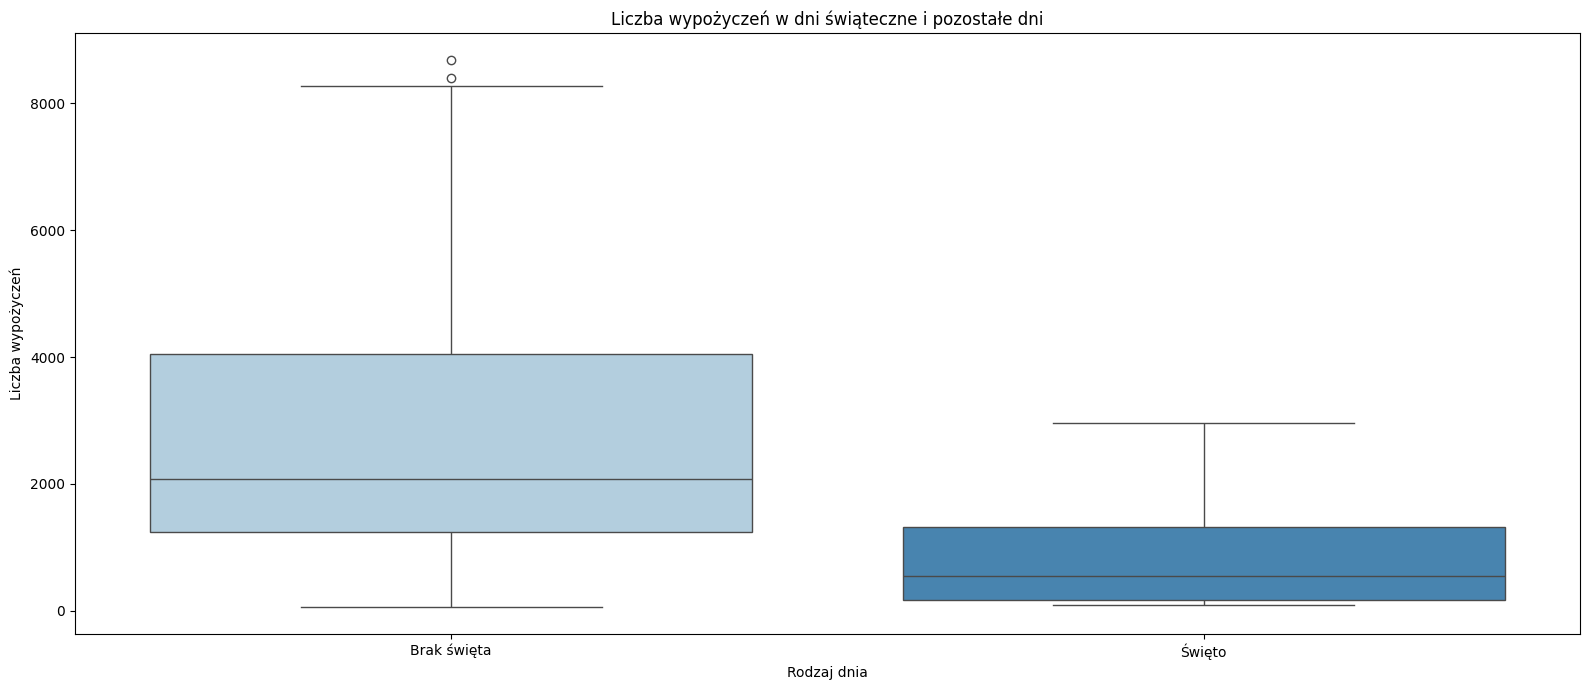

In [21]:
plt.figure(figsize=(16, 7))                                           # Utworzenie obszaru wykresu o wymiarach 16 × 7 cali

sns.boxplot(                                                           # Utworzenie wykresu pudełkowego porównującego rodzaje dni
    data=full_years,
    x='Holiday',
    y='Volume',
    hue='Holiday',                                                     # Przypisanie kolorów według wartości kolumny Holiday
    palette='Blues',
    legend=False                                                       # Ukrycie zbędnej legendy
)

plt.title('Liczba wypożyczeń w dni świąteczne i pozostałe dni')       # Nadanie tytułu wykresowi
plt.xlabel('Rodzaj dnia')                                              # Nadanie etykiety osi poziomej
plt.ylabel('Liczba wypożyczeń')                                        # Nadanie etykiety osi pionowej
plt.xticks([0, 1], ['Brak święta', 'Święto'])                         # Zamiana wartości 0 i 1 na czytelne opisy
plt.tight_layout()                                                     # Dopasowanie elementów wykresu
plt.show()                                                             # Wyświetlenie gotowego wykresu

Święto ma zdecydowany wpływ na liczbę wypożyczonych rowerów.

Sprawdźmy jeszcze zależność obserwacji od szeregu opóźnień. Wykres zależności obserwacji szeregu od opóźnień zwykle służy do sprawdzania autokorelacji. Jeśli na wykresie rozproszenia zauważalny jest jakikolwiek wzorzec, wówczas możemy sądzić, że szereg jest autoskorelowany. Jeśli punkty układają się w sposób losowy, wówczas będzie przypadkowym białym szumem.

In [22]:
# TLUMACZNIE

Drugi fragment dotyczy autokorelacji, czyli zależności bieżącej liczby wypożyczeń od wcześniejszych wartości tego samego szeregu.
Przykładowo:

-opóźnienie 1 porównuje dzisiejszą liczbę wypożyczeń z liczbą z poprzedniego dnia,
-opóźnienie 7 porównuje ją z tym samym dniem poprzedniego tygodnia,
-opóźnienie 14 — z wartością sprzed dwóch tygodni,
-opóźnienie 365 — z podobnym dniem poprzedniego roku.

Jeśli na wykresie punktowym wartości układają się mniej więcej wzdłuż rosnącej linii, oznacza to dodatnią autokorelację: po dniach z dużą liczbą wypożyczeń często występują podobnie wysokie wartości.

Jeżeli punkty układają się wzdłuż linii malejącej, występuje autokorelacja ujemna: po wysokich wartościach częściej pojawiają się niskie.
Jeśli punkty tworzą bezkształtną, losową chmurę, dla danego opóźnienia nie widać wyraźnej zależności.
W przypadku wypożyczeń rowerów można spodziewać się autokorelacji, ponieważ:
pogoda często utrzymuje się przez kilka kolejnych dni,
występuje tygodniowy cykl aktywności,
liczba wypożyczeń zależy od sezonu,
popularność wypożyczeń może zmieniać się długoterminowo.

„Biały szum” oznacza natomiast szereg losowych, wzajemnie niezależnych wartości, bez trendu, sezonowości i autokorelacji. Surowe dane o wypożyczeniach raczej nie będą białym szumem.
Ważna korekta językowa: powinno być „szereg jest autokorelowany”, a nie „autoskorelowany”. Ponadto brak wzorca na jednym wykresie opóźnienia nie wystarcza, aby uznać cały szereg za biały szum — należy sprawdzić wiele opóźnień, np. za pomocą wykresów ACF i testu Ljunga–Boxa.

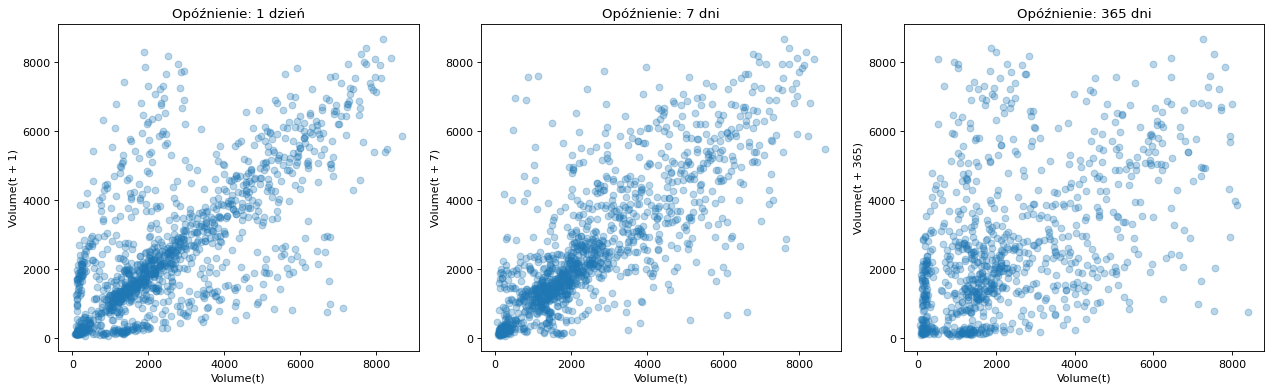

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=80)                  # Utworzenie figury z trzema wykresami opóźnień

pd.plotting.lag_plot(                                                    # Porównanie bieżących wartości z poprzednim dniem
    dataframe['Volume'],
    lag=1,                                                               # Ustawienie opóźnienia wynoszącego jeden dzień
    ax=axes[0],
    alpha=0.3                                                            # Ustawienie przezroczystości punktów
)
axes[0].set_title('Opóźnienie: 1 dzień')                                # Nadanie tytułu pierwszemu wykresowi
axes[0].set_xlabel('Volume(t)')                                         # Oznaczenie wartości bieżącej na osi X
axes[0].set_ylabel('Volume(t + 1)')                                     # Oznaczenie wartości przesuniętej na osi Y

pd.plotting.lag_plot(                                                    # Porównanie wartości oddalonych o jeden tydzień
    dataframe['Volume'],
    lag=7,                                                               # Ustawienie opóźnienia wynoszącego siedem dni
    ax=axes[1],
    alpha=0.3
)
axes[1].set_title('Opóźnienie: 7 dni')                                  # Nadanie tytułu drugiemu wykresowi
axes[1].set_xlabel('Volume(t)')
axes[1].set_ylabel('Volume(t + 7)')

pd.plotting.lag_plot(                                                    # Porównanie wartości oddalonych o około jeden rok
    dataframe['Volume'],
    lag=365,                                                             # Ustawienie opóźnienia wynoszącego 365 dni
    ax=axes[2],
    alpha=0.3
)
axes[2].set_title('Opóźnienie: 365 dni')                                # Nadanie tytułu trzeciemu wykresowi
axes[2].set_xlabel('Volume(t)')
axes[2].set_ylabel('Volume(t + 365)')

plt.tight_layout()                                                       # Dopasowanie odstępów między wykresami
plt.show()                                                               # Wyświetlenie gotowych wykresów

Uwaga: lag=365 oznacza 365 wierszy, a niekoniecznie 365 dni. Ponieważ w danych brakuje kilku dat, przed analizą należy uporządkować dane i utworzyć pełny dzienny indeks. W przeciwnym razie opóźnienia mogą nie odpowiadać rzeczywistym odstępom kalendarzowym

Przez to, że mamy sezonowość tygodniową, to wartość dzisiejsza jest bardziej podobna do wartości z poprzedniego tygodnia niż do wartości z wczoraj. Tutaj powinna zapalić Ci się lampka i podpowiedź, jak to wykorzystać, ale spokojnie – wrócimy jeszcze do tego.

Na tę część poświęciliśmy trochę czasu, ale uwierz nam – pomoże to przy przetworzeniu danych, a następnie przy modelowaniu.

In [24]:
# TLUMACZENIE

Oznacza to, że liczba wypożyczeń dzisiaj może być bardziej zbliżona do liczby wypożyczeń w tym samym dniu poprzedniego tygodnia niż wczoraj.
Przykładowo:
dzisiejszy poniedziałek porównujemy z poprzednim poniedziałkiem (lag=7),
porównanie dzisiejszego poniedziałku z niedzielą (lag=1) może wykazać słabsze podobieństwo.
Wynika to z tygodniowego rytmu wypożyczeń. Dni robocze mogą zachowywać się inaczej niż weekendy, dlatego obserwacje oddalone o 7 dni często są do siebie podobne.
„Lampka” oznacza sugestię, żeby wykorzystać tę zależność podczas budowania modelu. Można utworzyć cechy opóźnione:
dataframe['Volume_lag_1'] = dataframe['Volume'].shift(1)     # Liczba wypożyczeń wczoraj
dataframe['Volume_lag_7'] = dataframe['Volume'].shift(7)     # Liczba wypożyczeń tydzień wcześniej
dataframe['Volume_lag_14'] = dataframe['Volume'].shift(14)   # Liczba wypożyczeń dwa tygodnie wcześniej
Model otrzyma wtedy informację o wcześniejszych wartościach i może nauczyć się zależności:
Jeżeli w poprzedni poniedziałek wypożyczeń było dużo, w bieżący poniedziałek również prawdopodobnie będzie ich dużo.

Możesz także zastosować średnią kroczącą:
dataframe['Volume_rolling_7'] = (
    dataframe['Volume']
    .shift(1)                    # Wykluczenie wartości z bieżącego dnia
    .rolling(7)
    .mean()
)
shift(1) jest tutaj bardzo ważne — bez niego średnia zawierałaby dzisiejszą wartość Volume, czyli zmienną, którą model ma przewidzieć. Byłby to wyciek danych.
Ważne zastrzeżenie: cechę Volume_lag_7 można wykorzystać tylko wtedy, gdy podczas wykonywania prognozy wartość sprzed siedmiu dni jest już znana. Podział danych na treningowe i testowe powinien być chronologiczny, a nie losowy.

# Wpływ pogody na liczbę rowerzystów

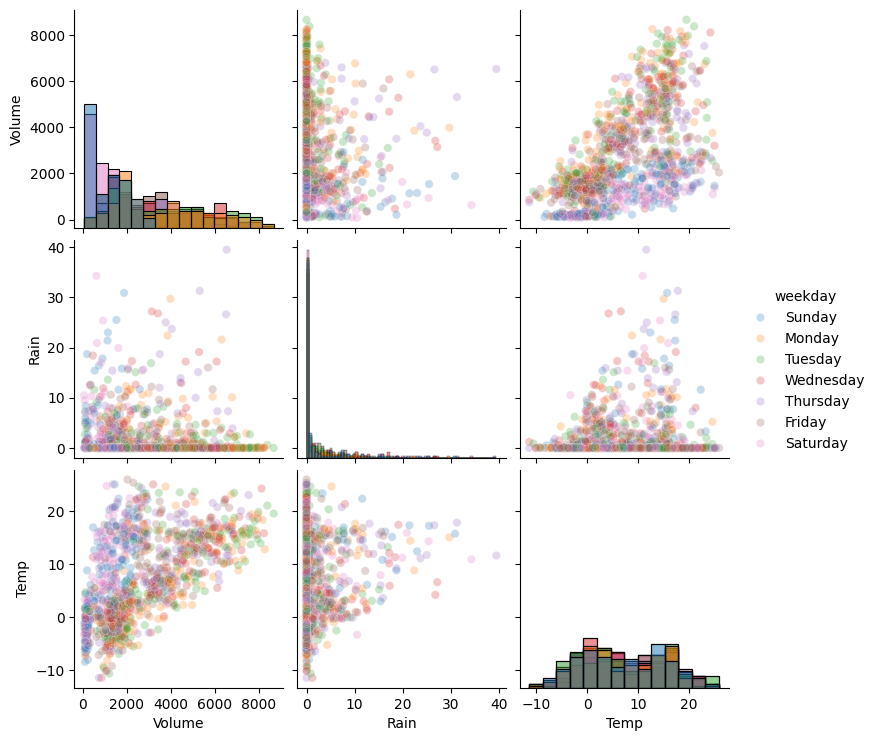

In [25]:
sns.pairplot(                                                        # Utworzenie macierzy wykresów zależności między zmiennymi
    full_years[['Volume', 'Rain', 'Temp', 'weekday']],               # Wybranie analizowanych kolumn
    hue='weekday',                                                    # Oznaczenie dni tygodnia różnymi kolorami
    kind='scatter',                                                   # Użycie wykresów punktowych poza przekątną
    diag_kind='hist',                                                 # Wyświetlenie histogramów na przekątnej
    plot_kws={'alpha': 0.25}                                         # Ustawienie przezroczystości punktów
)

plt.show()                                                            # Wyświetlenie gotowej macierzy wykresów

Wykres pozwala jednocześnie sprawdzić:
- zależność liczby wypożyczeń od temperatury,
- zależność liczby wypożyczeń od opadów,
- zależność między temperaturą i opadami,
- czy zależności różnią się w zależności od dnia tygodnia.
    
alpha=0.25 zwiększa przezroczystość punktów, dzięki czemu obszary z dużą liczbą nakładających się obserwacji są łatwiejsze do zauważenia.

Korelacja pomiędzy temperaturą a liczbą wypożyczonych rowerów jest jasna. Taka sytuacja nie zachodzi dla opadów deszczu – jednak zostawimy tę zmienną.

# 20.3 Przygotowanie danych

Znamy już problemy związane z naszym zbiorem danych, jak i również wiemy co wpływa na liczbę wypożyczonych rowerów. Przekształćmy zatem zbiór danych w taki sposób, aby poradzić sobie z problemami, oraz by model miał łatwiejsze zadanie przy prognozowaniu. Wykorzystamy do tego Pipeline, proces przetwarzania będzie bardziej automatyczny i gotowy do zaimplementowania na produkcję, jak i również będziemy pewni, że nie dojdzie do wycieku danych.

In [26]:
dataframe

,Date,Volume,Rain,Temp
0,2016-11-17,933.0,9.0,2.1
1,2016-11-18,1197.0,6.7,3.9
2,2016-11-19,243.0,5.4,2.0
3,2016-11-20,234.0,3.9,2.8
4,2016-11-21,2148.0,7.3,2.8
...,...,...,...,...
1268,2020-05-16,2484.0,0.0,6.6
1269,2020-05-17,1509.0,0.0,9.1
1270,2020-05-18,5775.0,0.0,9.3
1271,2020-05-19,6741.0,0.0,9.7


Jak pamiętasz, mamy brakujące dni, które powinny zostać dodane. Powinniśmy jest stworzyć. Stworzymy do tego własny Transformer AddMissingDates, który ustawi datę jako indeks, a następnie uzupełni brakujące dni pomiędzy minimalną a maksymalną datą.

In [27]:
class AddMissingDates(BaseEstimator, TransformerMixin):  # Definiuje transformer zgodny z interfejsem scikit-learn.
    def __init__(self, date_column):  # Inicjalizuje obiekt i przyjmuje nazwę kolumny z datami.
        self.date_column = date_column  # Zapisuje nazwę kolumny z datami.
        pass  # Nie wykonuje żadnej operacji; tę linię można usunąć.

    def fit(self, X, y=None):  # Dopasowuje transformer; tutaj nie wylicza żadnych parametrów.
        return self  # Zwraca bieżący obiekt, zgodnie z API scikit-learn.

    def transform(self, X, y=None):  # Przekształca przekazany zbiór danych.
        X_transformed = X.copy()  # Tworzy kopię danych, aby nie modyfikować oryginału.

        # Ustawia kolumnę z datami jako indeks.
        X_transformed = X_transformed.set_index(self.date_column)  # Przenosi wskazaną kolumnę do indeksu.
        X_transformed.index = pd.to_datetime(X_transformed.index)  # Konwertuje indeks na typ daty i czasu.

        # Tworzy pełny zakres dni i dodaje brakujące daty.
        new_idx = pd.date_range(X_transformed.index.min(), X_transformed.index.max())  # Generuje wszystkie dni od daty minimalnej do maksymalnej.
        X_transformed = X_transformed.reindex(new_idx)  # Dopasowuje dane do pełnego zakresu; brakujące wiersze zawierają NaN.
        return X_transformed  # Zwraca uzupełniony zbiór danych.

Kod tworzy własny transformer do pipeline’u scikit-learn. Ustawia daty jako indeks, generuje pełny dzienny zakres dat i dodaje brakujące dni jako nowe wiersze. Wartości w dodanych wierszach są domyślnie NaN.

Następnie implementujemy Pipeline z Transformerem AddMissingDates.

In [28]:
steps = [  # Tworzy listę kroków przetwarzania danych.
    ('add_missing_dates', AddMissingDates(date_column='Date'))  # Dodaje transformer uzupełniający brakujące daty z kolumny „Date”.
]  # Kończy definicję listy kroków.

data_preparation_pipeline = Pipeline(steps=steps)  # Tworzy pipeline scikit-learn z podanych kroków.
dataframe_prepared = data_preparation_pipeline.fit_transform(dataframe)  # Dopasowuje pipeline i przekształca ramkę danych.
dataframe_prepared  # Wyświetla przygotowaną ramkę danych w notebooku.


,Volume,Rain,Temp
2016-11-17,933.0,9.0,2.1
2016-11-18,1197.0,6.7,3.9
2016-11-19,243.0,5.4,2.0
2016-11-20,234.0,3.9,2.8
2016-11-21,2148.0,7.3,2.8
...,...,...,...
2020-05-16,2484.0,0.0,6.6
2020-05-17,1509.0,0.0,9.1
2020-05-18,5775.0,0.0,9.3
2020-05-19,6741.0,0.0,9.7


Kod tworzy jednoetapowy pipeline. Transformer AddMissingDates ustawia kolumnę Date jako indeks i dodaje brakujące dni pomiędzy najwcześniejszą a najpóźniejszą datą. Dla dodanych wierszy pozostałe kolumny będą zawierały NaN.

Porównaj ten dataset z tym surowym. Jak można zauważyć, data została ustawiona jako indeks. Widzimy też większą liczbę wierszy. Jest ona większa o liczbę brakujących dni. Wcześniej nie było daty 16 października 2017 roku. Sprawdźmy, czy teraz jest ta data.

In [29]:
dataframe_prepared.loc[dataframe_prepared.index=='2017-10-16',:]

,Volume,Rain,Temp
2017-10-16,NaN,NaN,NaN


# Uzupełnienie wartości brakujących

Daty mamy już wszystkie, jednak nie ma tam wartości. Aby nauczyć model, powinniśmy je uzupełnić. Czy dobrym rozwiązaniem będzie uzupełnienie jej średnią czy medianą ze zbioru treningowego? Będzie to dobre rozwiązanie, jednak można dokonać lepszej operacji, bardziej dokładnej. Podczas badania autokorelacji widzieliśmy, że wartość obecna jest zbliżona do wartości sprzed tygodnia, tak też uzupełnimy wartości brakujące – wartościami sprzed tygodnia. Wartości dla pogody uzupełnimy w podobny sposób. Gdybyśmy Cię poprosili o wskazanie pogody na dzień jutrzejszy bez sprawdzania internetu, to co zrobisz? Dobrym rozwiązaniem byłoby stwierdzenie, że jutro będzie taka sama pogoda, jak dziś? O dziwo jest to dobra prognoza pogody, często lepsza niż inne matematyczne algorytmy prognozujące pogodę. Dlatego brakującą pogodę uzupełnimy wartością z dnia poprzedniego

Tworzymy Transformer FillMissings, który będzie w powyższy sposób uzupełniał wartości brakujące.

In [30]:
class FillMissings(BaseEstimator, TransformerMixin):  # Definiuje transformer zgodny z API scikit-learn.
    def __init__(self):  # Poprawnie definiuje konstruktor klasy.
        pass  # Transformer nie wymaga parametrów inicjalizacyjnych.

    def fit(self, X, y=None):  # Dopasowuje transformer do danych.
        return self  # Nie wylicza parametrów, więc zwraca bieżący obiekt.

    def transform(self, X, y=None):  # Uzupełnia brakujące wartości.
        X_transformed = X.copy()  # Tworzy kopię danych wejściowych.
        X_transformed = X_transformed.sort_index()  # Ustawia dane chronologicznie.

        # Uzupełnia Volume wartością z tego samego dnia poprzedniego tygodnia.
        while X_transformed['Volume'].isna().any():  # Powtarza uzupełnianie, jeśli nadal występują braki.
            volume_before = X_transformed['Volume'].copy()  # Zapamiętuje stan kolumny przed uzupełnieniem.
            X_transformed['Volume'] = X_transformed['Volume'].fillna(  # Uzupełnia tylko brakujące wartości.
                X_transformed['Volume'].shift(7)  # Pobiera wartość sprzed siedmiu dni.
            )

            if X_transformed['Volume'].equals(volume_before):  # Sprawdza, czy udało się uzupełnić kolejne braki.
                break  # Kończy pętlę, gdy następna iteracja niczego już nie zmieni.

        # Uzupełnia pogodę ostatnią dostępną wartością.
        X_transformed['Rain'] = X_transformed['Rain'].ffill()  # Wypełnia także kilka kolejnych brakujących dni.
        X_transformed['Temp'] = X_transformed['Temp'].ffill()  # Wypełnia także kilka kolejnych brakujących dni.

        # Uzupełnia ewentualne braki na samym początku danych.
        X_transformed['Rain'] = X_transformed['Rain'].bfill()  # Pobiera pierwszą dostępną późniejszą wartość.
        X_transformed['Temp'] = X_transformed['Temp'].bfill()  # Pobiera pierwszą dostępną późniejszą wartość.

        return X_transformed  # Zwraca przygotowaną ramkę danych.

KOD POWYZEJ JEST INNY NIZ NA KURSIE PONIEWAZ TAMTEN NIE PRZEWIDYWAL TEGO ZE JESLI DNI SA POD RZAD TO I TAK ZOSTANIE MAM NAN. SPRAWDZENIE ZOSTALO ORGINALNIE ZROBIONE DLA JEDNEJ DATY A NIE DLA WSZYSTKICH. TEWAZ JEST GIT DLA WSZYSKITCH CO WIDAC NIZEJ 

Kod uzupełnia braki w Volume wartością sprzed siedmiu wierszy, a braki w Rain i Temp — wartością z poprzedniego wiersza. Jeśli odpowiednia wcześniejsza wartość również jest pusta albo nie istnieje, wynik nadal będzie NaN. Założenie „7 wierszy = tydzień” jest poprawne, jeśli dane mają jeden wiersz na każdy dzień i są uporządkowane chronologicznie.

Następnie dodajemy ten Transformer do naszego Pipeline przetwarzającego dane.

In [31]:
steps = [
    ('add_missing_dates', AddMissingDates(date_column='Date')),
    ('fill_missing_values', FillMissings())
]
data_preparation_pipeline = Pipeline(steps = steps)
dataframe_prepared = data_preparation_pipeline.fit_transform(dataframe)
dataframe_prepared

,Volume,Rain,Temp
2016-11-17,933.0,9.0,2.1
2016-11-18,1197.0,6.7,3.9
2016-11-19,243.0,5.4,2.0
2016-11-20,234.0,3.9,2.8
2016-11-21,2148.0,7.3,2.8
...,...,...,...
2020-05-16,2484.0,0.0,6.6
2020-05-17,1509.0,0.0,9.1
2020-05-18,5775.0,0.0,9.3
2020-05-19,6741.0,0.0,9.7


In [32]:
steps = [  # Tworzy listę kolejno wykonywanych etapów przetwarzania danych.
    ('add_missing_dates', AddMissingDates(date_column='Date')),  # Dodaje brakujące daty między najwcześniejszą a najpóźniejszą datą.
    ('fill_missing_values', FillMissings())  # Uzupełnia braki w kolumnach `Volume`, `Rain` i `Temp`.
]  # Kończy definicję listy kroków.

data_preparation_pipeline = Pipeline(steps=steps)  # Tworzy pipeline scikit-learn z dwóch transformerów.
dataframe_prepared = data_preparation_pipeline.fit_transform(dataframe)  # Dopasowuje pipeline i wykonuje wszystkie kroki na danych.
dataframe_prepared  # Wyświetla przygotowaną ramkę danych w notebooku.

,Volume,Rain,Temp
2016-11-17,933.0,9.0,2.1
2016-11-18,1197.0,6.7,3.9
2016-11-19,243.0,5.4,2.0
2016-11-20,234.0,3.9,2.8
2016-11-21,2148.0,7.3,2.8
...,...,...,...
2020-05-16,2484.0,0.0,6.6
2020-05-17,1509.0,0.0,9.1
2020-05-18,5775.0,0.0,9.3
2020-05-19,6741.0,0.0,9.7


Sprawdźmy czy mamy wartości, które wcześniej były brakujące.

In [33]:
dataframe_prepared.loc[dataframe_prepared.index=='2017-10-16',:]

,Volume,Rain,Temp
2017-10-16,4947.0,0.0,9.6


In [34]:
dates_to_check = [  # Tworzy listę dat, które chcemy sprawdzić.
    '2017-10-16',
    '2019-01-14',
    '2019-06-07',
    '2019-06-08',
    '2019-06-09',
    '2019-06-10',
    '2019-08-14',
    '2019-08-15'
]

dataframe_prepared.loc[dataframe_prepared.index.isin(dates_to_check), :]  # Wyświetla wiersze odpowiadające wszystkim wskazanym datom.

,Volume,Rain,Temp
2017-10-16,4947.0,0.0,9.6
2019-01-14,2241.0,0.0,-3.5
2019-06-07,3870.0,1.7,18.9
2019-06-08,771.0,1.7,18.9
2019-06-09,2448.0,1.7,18.9
2019-06-10,5595.0,1.7,18.9
2019-08-14,5988.0,0.0,16.7
2019-08-15,6096.0,0.0,16.7


# Feature Engineering - Inżynieria cech

Póki co naprawiliśmy problemy, które mieliśmy w danych. Teraz czas na inżynierię cech. Andrew Ng kiedyś powiedział, że “Stosowane uczenie maszynowe to w zasadzie inżynieria cech”. Bardzo często mówi się, że dane są paliwem dla uczenia maszynowego. Natomiast w rzeczywistości nie jest to do końca prawdą. Gdyby wziąć po prostu dane jakie mamy na wejściu, to w większości przypadków nie przygotowalibyśmy dobrych modeli. Lepiej mówić, że dane są jak ropa naftowa. Zatem najpierw należy przeprowadzić transformację surowej ropy w paliwo. Ta transformacja w naszym przypadku to inżynieria cech, po angielsku Feature Engineering.

Tworzymy nowe cechy w oparciu o już istniejące, które umożliwiają działanie algorytmów uczenia maszynowego. Poprawne przygotowanie danych bardzo zwiększa ich jakość, ponieważ surowe dane przekształcamy w informacje, które model przekształci w wiedzę. Wtedy też model lepiej może rozumieć świat i będzie dawał lepszej jakości prognozy.

Obecnie możemy zobaczyć trend w wykorzystywaniu modeli takich jak XGBoost czy sieć neuronowa. Oczywiście, czasem nie mamy wyboru, przykładem może być klasyfikacja obiektu na zdjęciu z wykorzystaniem konwolucyjnych sieci neuronowych. Niemniej zawsze powinniśmy dobrze wykonać zadanie analizy danych i wnioski, które wyciągniemy powinniśmy przełożyć na przekształcenie tychże danych. Regresja logistyczna może dać lepszą dokładność przy dobrze przekształconych danych niż XGBoost na surowych danych. Ponadto jeśli model jest mniej złożony to również lepiej interpretowalny, co często też jest istotne dla biznesu. Dzięki temu wiemy i potrafimy wyjaśnić, jak zmienne wpływają na prognozę naszego modelu.

Do stworzenia nowych cech dla X zaimplementujemy Transformer FeatureEngineeringTransformer.

Załóżmy, że robimy prognozę dla 2020-05-20, możemy wykorzystać dane pogodowe dla tego dnia (zakładamy, że wykorzystujemy prognozę tej pogody i jest ona taka sama jak wartość rzeczywista). Pamiętaj, że prognoza dla tego dnia musi być wykonana tydzień wcześniej, zatem ostatnią znaną wartością wypożyczonych rowerów będzie wartość z dnia 2020-05-13 – zmienna Volume_lag_7.

Na podstawie Volume_lag_7 tworzymy opóźnione wartości, czyli ile wypożyczeń było dzień wcześniej, dwa dni wcześniej, aż do dwóch tygodni wcześniej. Jest to prosty sposób, aby szereg czasowy przekształcić w problem uczenia nadzorowanego. Tutaj z kolei nie ma tych cech dla pierwszych wartości, ponieważ nie ma skąd ich wziąć. Te pierwsze wartości będziemy musieli usunąć. Zatem im większe przesuwne okno, tym więcej wartości tracimy.

Następnym krokiem po dodaniu surowych wartości opóźnionych jest dodanie kroczących statystyk, czyli dla przesuwanego okna wyliczamy różne statystyki. Dla okien o szerokości 7 oraz 14 dni wyliczamy średnią, odchylenie standardowe oraz wartość minimalną i maksymalną.

W naszym szeregu czasowym występuje sezonowość, czyli w konkretnym okresie roku/tygodnia występuje zwiększona liczba wypożyczonych rowerów niż w innym. Aby wykorzystać okres roku/dzień tygodnia jako informację, przekształcamy dzień w roku/dzień w tygodniu na zmienne cykliczne, jakimi jest sinus i cosinus. Tym samym jedną zmienną (dzień w roku lub dzień w tygodniu) przekształcamy w dwie. W związku z tym dwie zmienne przekształcamy w cztery zmienne. To samo podejście możemy zastosować dla innych zmiennych cyklicznych, jak na przykład godzina. Na przykładzie dni tygodnia wyjaśnimy czemu to przekształcenie może być lepsze niż inne.

Dodajemy zmienną z rokiem, ponieważ widoczny w danych jest trend pomiędzy 2017 a 2018 rokiem. Dlatego chcemy rozróżnić wartości pomiędzy tymi okresami. Będziemy prognozować wartość surową, gdyby trend nadal obowiązywał, to nie możemy tak robić. Gdyby był trend, to moglibyśmy prognozować wartość zróżnicowaną, która jest popularnym i szeroko stosowanym przekształceniem danych, dzięki któremu dane szeregów czasowych stają się stacjonarne. Różnicowanie możesz znać również jako Differencing, czyli odjęcie poprzedniej obserwacji od bieżącej. Możemy również prognozować zlogarytmowany stosunek przyszłej wartości przez obecną. Wykorzystując któreś z tych przekształceń do stworzenia nowych wartości, prognozujemy dynamikę i możemy prognozować wartości surowe spoza zakresu danych treningowych.

Dodajemy również święta, jednak w tym przypadku uogólniamy święta do informacji, czy było święto czy nie.

Na koniec usuwamy obserwacje z brakującymi wartościami powstałymi przez to, że są to pierwsze obserwacje i nie ma skąd wziąć dla nich przeszłości.

In [35]:
class FeatureEngineeringTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        def encode_time(X, col, max_val):
            X[col + '_sin'] = np.sin(2 * np.pi * X[col] / max_val)
            X[col + '_cos'] = np.cos(2 * np.pi * X[col] / max_val)
            X.drop(col, axis='columns', inplace=True)
            return X

        def get_holiday(row):
            holiday = holidays_Norway.get(row['Date'])

            if holiday is None:
                return 0
            elif holiday != 'Søndag':
                if 'Søndag' in holiday:
                    holiday = holiday.replace('Søndag', '')
                    holiday = holiday.replace(',', '')
                    holiday = holiday.strip()
                    return 1
                else:
                    return 1
            else:
                return 0

        X_transformed = X.copy()

        # Liczba wypożyczeń sprzed 7 dni
        X_transformed['Volume_lag_7D'] = X_transformed['Volume'].shift(7)

        # Liczba wypożyczeń sprzed 8–21 dni
        for lag in range(1, 15):
            X_transformed[f'Volume_lag_{lag + 7}D'] = (
                X_transformed['Volume_lag_7D'].shift(lag)
            )

        # Statystyki obliczane na danych dostępnych co najmniej 7 dni wcześniej
        for window in [7, 14]:
            X_transformed[f'Volume_window_{window}D_mean'] = (
                X_transformed['Volume_lag_7D'].rolling(window=window).mean()
            )
            X_transformed[f'Volume_window_{window}D_std'] = (
                X_transformed['Volume_lag_7D'].rolling(window=window).std()
            )
            X_transformed[f'Volume_window_{window}D_min'] = (
                X_transformed['Volume_lag_7D'].rolling(window=window).min()
            )
            X_transformed[f'Volume_window_{window}D_max'] = (
                X_transformed['Volume_lag_7D'].rolling(window=window).max()
            )

        # Sezonowość roczna
        X_transformed['day_of_year'] = X_transformed.index.dayofyear
        X_transformed = encode_time(X_transformed, 'day_of_year', 366)

        # Sezonowość tygodniowa
        X_transformed['weekday'] = X_transformed.index.weekday
        X_transformed = encode_time(X_transformed, 'weekday', 7)

        # Rok
        X_transformed['year'] = X_transformed.index.year

        # Informacja o świętach
        X_transformed['Date'] = X_transformed.index
        X_transformed['Holiday'] = X_transformed.apply(get_holiday, axis=1)
        X_transformed.drop(['Date'], axis=1, inplace=True)

        # Usunięcie wierszy z brakującymi danymi
        X_transformed.dropna(inplace=True)

        return X_transformed

Transformer tworzy:
- wartości Volume opóźnione o 7–21 dni,
- statystyki kroczące z okresów 7 i 14 dni,
- cykliczne reprezentacje dnia roku i dnia tygodnia,
- cechę określającą rok,
- informację o norweskich świętach.
    
Na końcu usuwa niekompletne wiersze, które powstają naturalnie przez shift() i rolling().

Następnie do Pipeline dodajemy Transformer FeatureEngineeringTransformer, który tworzy nowe cechy dla X.

In [36]:
steps = [
    ('add_missing_dates', AddMissingDates(date_column='Date')),
    ('fill_missing_values', FillMissings()),
    ('feature_engineering', FeatureEngineeringTransformer())
]

data_preparation_pipeline = Pipeline(steps = steps)
dataframe_prepared = data_preparation_pipeline.fit_transform(dataframe)
dataframe_prepared

,Volume,Rain,Temp,Volume_lag_7D,Volume_lag_8D,Volume_lag_9D,Volume_lag_10D,Volume_lag_11D,Volume_lag_12D,Volume_lag_13D,...,Volume_window_14D_mean,Volume_window_14D_std,Volume_window_14D_min,Volume_window_14D_max,day_of_year_sin,day_of_year_cos,weekday_sin,weekday_cos,year,Holiday
2016-12-08,1743.0,10.3,5.7,1620.0,1908.0,1884.0,2175.0,396.0,384.0,1638.0,...,1407.642857,761.568483,234.0,2175.0,-0.384665,0.923056,0.433884,-0.900969,2016,0
2016-12-09,1608.0,0.0,3.4,1464.0,1620.0,1908.0,1884.0,2175.0,396.0,384.0,...,1426.714286,759.227282,234.0,2175.0,-0.368763,0.929523,-0.433884,-0.900969,2016,0
2016-12-10,261.0,0.3,2.1,213.0,1464.0,1620.0,1908.0,1884.0,2175.0,396.0,...,1424.571429,762.858865,213.0,2175.0,-0.352752,0.935717,-0.974928,-0.222521,2016,0
2016-12-11,354.0,3.4,0.5,246.0,213.0,1464.0,1620.0,1908.0,1884.0,2175.0,...,1425.428571,761.423638,213.0,2175.0,-0.336637,0.941634,-0.781831,0.623490,2016,0
2016-12-12,1941.0,0.0,-1.1,2079.0,246.0,213.0,1464.0,1620.0,1908.0,1884.0,...,1420.500000,756.594775,213.0,2175.0,-0.320423,0.947274,0.000000,1.000000,2016,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-05-16,2484.0,0.0,6.6,3681.0,4884.0,5649.0,6126.0,5853.0,4962.0,3072.0,...,4090.500000,1326.470200,2049.0,6126.0,0.710135,-0.704066,-0.974928,-0.222521,2020,0
2020-05-17,1509.0,0.0,9.1,1320.0,3681.0,4884.0,5649.0,6126.0,5853.0,4962.0,...,3925.928571,1517.910429,1320.0,6126.0,0.697944,-0.716152,-0.781831,0.623490,2020,1
2020-05-18,5775.0,0.0,9.3,5304.0,1320.0,3681.0,4884.0,5649.0,6126.0,5853.0,...,4157.571429,1457.674160,1320.0,6126.0,0.685548,-0.728028,0.000000,1.000000,2020,0
2020-05-19,6741.0,0.0,9.7,4881.0,5304.0,1320.0,3681.0,4884.0,5649.0,6126.0,...,4271.571429,1446.550417,1320.0,6126.0,0.672949,-0.739689,0.781831,0.623490,2020,0


Stworzyliśmy nowe cechy, na podstawie których będziemy prognozować liczbę zamówionych rowerów. Przez te nowe zmienne straciliśmy też 25 pierwszych obserwacji. Jeśli rozszerzylibyśmy okno, to liczba obserwacji do usunięcia byłaby większa.

In [37]:
print("Liczba wierszy przed transformacją:", len(dataframe_prepared))

dataframe_features = FeatureEngineeringTransformer().fit_transform(
    dataframe_prepared
)

print("Liczba wierszy po transformacji:", len(dataframe_features))
print(
    "Liczba usuniętych wierszy:",
    len(dataframe_prepared) - len(dataframe_features)
)

Liczba wierszy przed transformacją: 1260
Liczba wierszy po transformacji: 1239
Liczba usuniętych wierszy: 21


STRACILISMY 21 a nie 25 wierszy - kolejny blad w kursie 

Oznacza to, że podczas tworzenia cech historycznych funkcje shift() i rolling() wygenerowały wartości NaN na początku zbioru danych.
Przykładowo:
shift(7) potrzebuje danych sprzed 7 dni, więc dla pierwszych 7 obserwacji nie można wyliczyć tej cechy.
Największe opóźnienie, Volume_lag_21D, powoduje brak danych w pierwszych 21 wierszach.
Średnia krocząca dla 14 dni, obliczana na Volume_lag_7D, wymaga najpierw przesunięcia o 7 dni, a później zebrania 14 obserwacji.
Dla okna 14-dniowego pierwsza kompletna wartość pojawia się po:
7 dni przesunięcia + 13 wcześniejszych dni okna = 20 brakujących obserwacji
W tym kodzie największe opóźnienie lub okno powinno więc powodować utratę około 21 pierwszych obserwacji, a nie 25. Dokładną liczbę mogą zwiększać wcześniejsze braki w danych, które następnie usuwa:

# Podział danych na X i y

Zmienną objaśnianą (y) jest zmienna Volume, czyli prawdziwa wartość liczby wypożyczonych rowerów z dnia, który jest indeksem.

Zmienne objaśniające (X) to pozostałe zmienne, stworzone podczas inżynierii cech.

In [38]:
X = dataframe_prepared.drop(['Volume'], axis=1)  # Tworzy zbiór cech, usuwając z danych kolumnę prognozowaną `Volume`.
y = dataframe_prepared['Volume']  # Tworzy zmienną docelową zawierającą liczbę wypożyczonych rowerów.

Kod dzieli przygotowane dane na:
X – zmienne wejściowe, na podstawie których model będzie prognozował,
y – zmienną docelową Volume, czyli liczbę wypożyczonych rowerów.
W tym przypadku ważna jest jednak kolejność etapów. FeatureEngineeringTransformer wykorzystuje kolumnę Volume do tworzenia opóźnień i statystyk kroczących, dlatego nie można usunąć jej przed zastosowaniem tego transformera.

# Podział danych na zbiór treningowy i testowy

Do tej pory zazwyczaj korzystaliśmy z funkcji train_test_split z biblioteki scikit-learn. Teraz też moglibyśmy z tego skorzystać, pamiętając o tym, że nie możemy tasować obserwacji, ponieważ jak już wiesz, są one zależne od siebie w czasie! W dodatku zarząd naszej firmy powiedział nam, że chciałby zobaczyć backtesty (czyli wyniki na zbiorze testowym) dla 2020 roku i wtedy zdecyduje, czy zamierza wdrażać nasze rozwiązanie. Podzielmy zatem nasz zbiór danych w oparciu o indeks. W związku z tym, że zarząd chce aby zbiorem testowym był 2020 rok, pierwsza obserwacja z tego zbioru to 2020-01-01. W związku z tym indeksy ze zbioru testowego będą równe lub większe niż 2020-01-01, a indeksy ze zbioru treningowego będą mniejsze niż ta data.

In [39]:
first_test_date = dt.datetime.strptime('2020-01-01', '%Y-%m-%d')  # Zamienia tekstową datę na obiekt `datetime`, wyznaczający początek zbioru testowego.

X_train = X[X.index < first_test_date].copy()  # Wybiera cechy z okresu przed 1 stycznia 2020 roku.
y_train = y[y.index < first_test_date].copy()  # Wybiera wartości docelowe z okresu przed 1 stycznia 2020 roku.

X_test = X[X.index >= first_test_date].copy()  # Wybiera cechy od 1 stycznia 2020 roku.
y_test = y[y.index >= first_test_date].copy()  # Wybiera wartości docelowe od 1 stycznia 2020 roku.

# Selekcja zmiennych

Wykorzystując feature engineering, stworzyliśmy wiele cech, przez co napotykamy na problem klątwy wielowymiarowości, jak i zdarza się, że cechy są skorelowane pomiędzy sobą, stąd wiele z nich niesie tę samą informację, przez co może się okazać, że model uznaje jedną informację za ważniejszą, nawet jeśli tak nie jest w rzeczywistości. Innym powodem jest fakt, że nie chcemy uczyć modelu szumu. Stąd konieczność stosowania selekcji cech.

Selekcję cech możemy zastosować w oparciu o filtry (np. korelacja, wartość informacyjna), metody własne modeli (regularyzacja Lasso), wrappery (nauczyć taką kombinacją zmiennych, która daje najlepsze rezultaty) czy metody hybrydowe. My w tej części skorzystamy z metody własnej Random Forest, która jest Feature Importance – ważnością cech. Przed nauczeniem docelowego modelu, nauczymy wcześniej model, dzięki któremu wybierzemy cechy. Las losowy składa się z wielu drzew, jednak żadne drzewo nie ma dostępu do wszystkich cech i obserwacji. Dzięki temu daje to im niezależność, stąd nazewnictwo – Las losowy. Im częściej jest cecha wykorzystywana do podziału to też daje ona większy zysk informacyjny. Feature Importance to procent występowania zmiennej w węźle.

Weźmiemy pod uwagę jedynie te cechy, których ważność jest większa niż 0.75%, czyli mniej niż 1%. Wartość została wybrana arbitralnie, oczywiście można ‘ubrać’ to w Transformer i tę wartość traktować jako hiperparametr. Część ze zmiennych niesie podobną informację, na przykład wartości opóźnione dla różnego laga. Takie zmienne umieścimy do jednego koszyka (busket) i wybierzemy jedną z największą ważnością.

importances = RandomForestRegressor(n_estimato

In [40]:
importances = RandomForestRegressor(  # Tworzy model lasu losowego do oceny ważności cech.
    n_estimators=1000,  # Buduje las składający się z 1000 drzew.
    max_depth=20,  # Ogranicza maksymalną głębokość każdego drzewa do 20 poziomów.
    n_jobs=-1,  # Wykorzystuje wszystkie dostępne rdzenie procesora.
    random_state=42  # Zapewnia powtarzalność wyników.
).fit(X_train, y_train).feature_importances_  # Trenuje model i pobiera ważności poszczególnych cech.

features = pd.concat([  # Łączy nazwy cech z obliczonymi wartościami ważności.
    pd.DataFrame(X_train.columns, columns=['feat']),  # Tworzy tabelę z nazwami cech.
    pd.DataFrame(importances, columns=['importance'])  # Tworzy tabelę z ważnościami cech.
], axis=1).sort_values(  # Łączy tabele kolumnowo i rozpoczyna sortowanie.
    by='importance',  # Sortuje według ważności cechy.
    ascending=False  # Umieszcza najważniejsze cechy na początku.
)

features = features[features['importance'] > 0.0075]  # Pozostawia cechy o ważności większej niż 0,0075.

features.loc[features['feat'].str.contains('Volume_lag_'), 'Bucket'] = 'lag'  # Przypisuje opóźnione wartości do grupy `lag`.
features.loc[features['feat'].str.contains('mean'), 'Bucket'] = 'mean'  # Przypisuje średnie kroczące do grupy `mean`.
features.loc[features['feat'].str.contains('std'), 'Bucket'] = 'std'  # Przypisuje odchylenia standardowe do grupy `std`.
features.loc[features['feat'].str.contains('min'), 'Bucket'] = 'min'  # Przypisuje minima kroczące do grupy `min`.
features.loc[features['feat'].str.contains('max'), 'Bucket'] = 'max'  # Przypisuje maksima kroczące do grupy `max`.

display(features)  # Wyświetla ważne cechy przed usunięciem powtarzających się kategorii.

features = features[  # Filtruje tabelę ważnych cech.
    (~features.duplicated(subset='Bucket', keep='first'))  # Zachowuje tylko najważniejszą cechę z każdej grupy.
    | features['Bucket'].isnull()  # Zachowuje wszystkie cechy, które nie należą do żadnej z grup.
]

features = list(features['feat'].values)  # Zamienia wybrane nazwy cech na zwykłą listę.

print(f'Liczba zmiennych: {len(features)}')  # Wyświetla liczbę wybranych cech.
print(f'Zmienne: {features}')  # Wyświetla nazwy wybranych cech.

,feat,importance,Bucket
2,Volume_lag_7D,0.639551,lag
9,Volume_lag_14D,0.064570,lag
1,Temp,0.032416,NaN
25,day_of_year_sin,0.025023,NaN
26,day_of_year_cos,0.024852,NaN
20,Volume_window_7D_max,0.021982,max
16,Volume_lag_21D,0.016827,lag
30,Holiday,0.015968,NaN
22,Volume_window_14D_std,0.015397,std
24,Volume_window_14D_max,0.014200,max


Liczba zmiennych: 10
Zmienne: ['Volume_lag_7D', 'Temp', 'day_of_year_sin', 'day_of_year_cos', 'Volume_window_7D_max', 'Holiday', 'Volume_window_14D_std', 'Rain', 'Volume_window_14D_min', 'weekday_sin']


Kod wykorzystuje RandomForestRegressor do wstępnego wyboru najważniejszych zmiennych. Następnie:
- Odrzuca cechy o ważności nieprzekraczającej 0.0075.
- Grupuje podobne cechy historyczne.
- Z każdej grupy pozostawia tylko najważniejszą cechę.
- Zachowuje wszystkie istotne cechy, które nie należą do żadnej grupy.

Mamy już wyselekcjonowany zbiór cech, zmniejszyliśmy go o ponad 2/3. Wyfiltrujmy z X tylko te zmienne, które wybrano podczas selekcji cech.

In [41]:
X_train = X_train[features]
X_test = X_test[features]

# 20.4. Modelowanie i ewaluacja

Niektórym osobom na początku nauki, zdarza się popełnić pewien błąd – zbyt szybko przechodzą do tego punktu, bądź co gorsza, zaczynają od modelowania. Dobrego analityka danych cechuje świadomość pracy nad danymi i robi to zgodnie z tym, jak my teraz.

W tej części połączymy dwa następne etapy.

To co, jaki model trenujemy? Nie tak szybko ???? Przypomnij sobie początek modułu, jak obecnie nasze przedsiębiorstwo dokonuje prognozy – jest to średnia z wartości sprzed tygodnia oraz sprzed roku! Warto porównać nasz model do takiej prognozy. Jeśli nie zrobilibyśmy tego, a podczas prezentacji zrobiłby to prezes naszej spółki i okazałoby się, że nasz model jest gorszy, to trochę wstyd. Nawet, jeśli nie mamy informacji jak obecnie rozwiązywany jest problem, to warto tworzyć samemu taki model podstawowy – Baseline.

# Baseline

Model podstawowy, to taki, do którego porownujemy nasze modele - może być to prosta statystyka, jak średnia, bądź coś bardziej zaawansowanego, ale nadal podstawowego - u nas to będzie średnia z wartości, która była rok temu oraz tydzień wcześniej. Policzmy zatem Forecast dla zbioru testowego.

In [42]:
prediction_baseline = y.copy()  # Tworzy kopię szeregu z rzeczywistą liczbą wypożyczeń.

prediction_baseline = np.round(  # Zaokrągla prognozy do całkowitej liczby rowerów.
    (
        prediction_baseline.shift(367)  # Pobiera liczbę wypożyczeń sprzed 367 dni.
        + prediction_baseline.shift(7)  # Pobiera liczbę wypożyczeń sprzed 7 dni.
    ) / 2  # Oblicza średnią z dwóch wartości historycznych.
)

prediction_baseline.dropna(inplace=True)  # Usuwa dni, dla których nie można obliczyć prognozy.

prediction_baseline = prediction_baseline[  # Ogranicza prognozy do okresu testowego.
    prediction_baseline.index >= first_test_date  # Wybiera daty od początku zbioru testowego.
]

prediction_baseline  # Wyświetla prognozy modelu bazowego.

2020-01-01     146.0
2020-01-02     172.0
2020-01-03     238.0
2020-01-04     884.0
2020-01-05    1119.0
               ...  
2020-05-16    5446.0
2020-05-17    4047.0
2020-05-18    3152.0
2020-05-19    2898.0
2020-05-20    4202.0
Freq: D, Name: Volume, Length: 141, dtype: float64

Kod tworzy prostą prognozę bazową. Dla każdego dnia przewidywana liczba wypożyczeń jest średnią z:
liczby wypożyczeń sprzed 7 dni,
liczby wypożyczeń sprzed 367 dni.
Przykładowo:
prognoza = (wartość sprzed 7 dni + wartość sprzed 367 dni) / 2
Taki model uwzględnia sezonowość tygodniową i roczną. Przesunięcie o 367 dni zamiast 365 może służyć zachowaniu tego samego dnia tygodnia, ponieważ 364 dni to dokładnie 52 tygodnie. Warto jednak sprawdzić, czy 367 jest celowym wyborem.
shift() przesuwa dane o liczbę wierszy, a nie bezpośrednio o liczbę dni. Kod działa prawidłowo, jeśli indeks jest uporządkowany i zawiera dokładnie jeden wiersz dla każdego dnia.

W IT jesteśmy leniwi, nie lubimy dublować kodu, dlatego stwórzmy funkcję, której podawać będziemy wartość prawdziwą ze zbioru testowego oraz predykcje modeli. Będzie to wizualna ocena modelu.

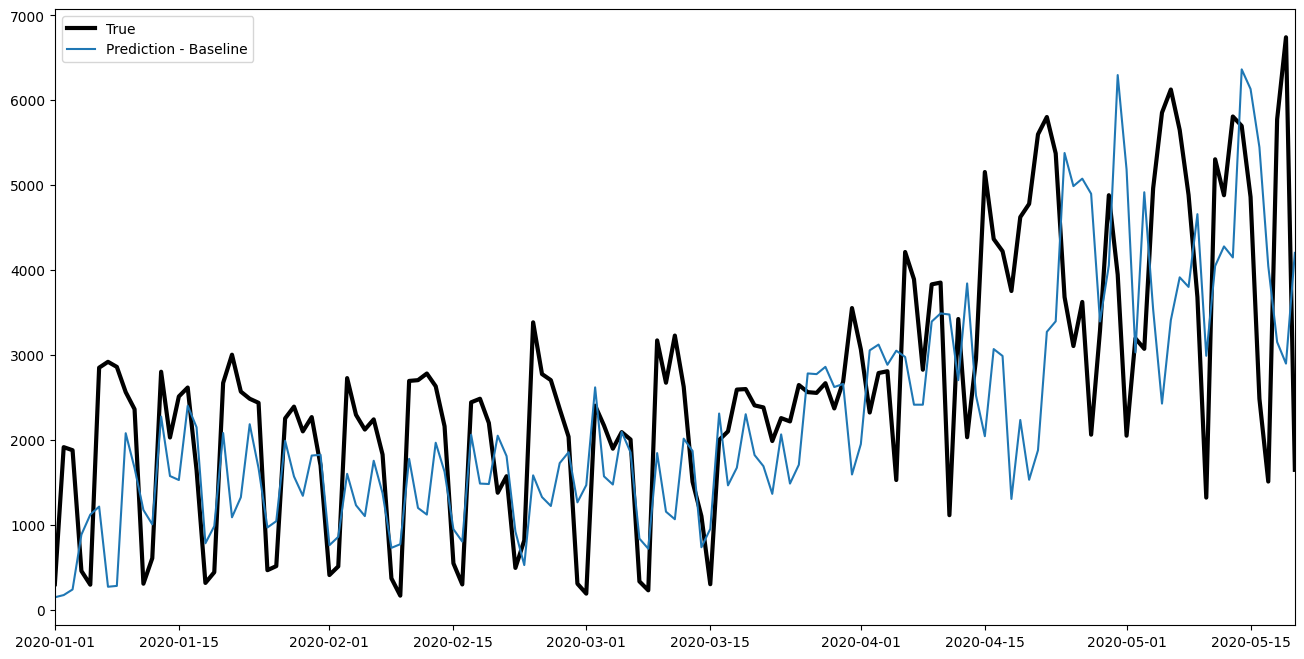

In [43]:
def plot_prediction_vs_true(yhat_list, yhat_names, ytest):  # Definiuje funkcję porównującą prognozy z wartościami rzeczywistymi.
    plt.figure(figsize=(16, 8), dpi=100)  # Tworzy wykres o wymiarach 16 × 8 cali i rozdzielczości 100 DPI.
    plt.plot(ytest, color='black', label='True', linewidth=3)  # Rysuje rzeczywiste wartości jako grubą czarną linię.

    for yhat, yname in zip(yhat_list, yhat_names):  # Łączy każdą prognozę z odpowiadającą jej nazwą.
        plt.plot(yhat, label=f'Prediction - {yname}')  # Rysuje linię prognozy i dodaje jej nazwę do legendy.

    plt.xlim([ytest.index.min(), ytest.index.max()])  # Ogranicza oś X do zakresu dat zbioru testowego.
    plt.legend(loc='upper left')  # Umieszcza legendę w lewym górnym rogu.
    plt.show()  # Wyświetla gotowy wykres.


plot_prediction_vs_true(  # Wywołuje funkcję porównującą prognozę bazową z prawdziwymi wartościami.
    yhat_list=[prediction_baseline],  # Przekazuje listę zawierającą prognozę bazową.
    yhat_names=['Baseline'],  # Nadaje prognozie nazwę wyświetlaną w legendzie.
    ytest=y_test  # Przekazuje rzeczywiste wartości ze zbioru testowego.
)

Funkcja może jednocześnie porównać kilka modeli. yhat_list zawiera prognozy, a yhat_names ich nazwy. Funkcja zip() łączy je parami, np. pierwszą prognozę z pierwszą nazwą.
Czarna linia przedstawia rzeczywistą liczbę wypożyczeń, a pozostałe linie przedstawiają prognozy. Im bliżej linia prognozy znajduje się czarnej linii, tym lepiej model przewiduje wartości.

Trzeba przyznać, że Forecast stworzony w oparciu o taką prostą statystykę wygląda naprawdę dobrze.

Ponownie cofnij się pamięcią do tego, co było na początku.

Niewystarczająca liczba rowerów na stanowiskach to utracony zysk o wartości 10zł, taki jest średni zysk z wypożyczenia jednego roweru na tej trasie.

Jeśli zbyt wiele rowerów jest na stanowisku to utrzymujemy rowery, które nie przynoszą zysku, a wcześniej musieliśmy je przywieźć – średni dzienny koszt, który ponosimy przez niewypożyczenie roweru to 1zł.

Zła prognoza generuje nam dodatkowe koszty, jednak błąd przeszacowania nie jest równy niedoszacowaniu. Stwórzmy funkcję, która oblicza koszt spowodowany złą prognozą:

In [44]:
def Cost(y_true, y_pred):  # Definiuje funkcję obliczającą koszt błędnych prognoz.
    def apply_cost(x):  # Definiuje sposób naliczania kosztu dla pojedynczego błędu.
        if x < 0:  # Sprawdza, czy prognoza była niższa od wartości rzeczywistej.
            x = np.abs(x) * 10  # Mnoży niedoszacowanie przez 10.
        return x  # Zwraca koszt błędu; przeszacowanie pozostaje bez mnożnika.

    y_pred = np.round(y_pred)  # Zaokrągla prognozowaną liczbę rowerów do liczby całkowitej.
    cost = y_pred - y_true  # Oblicza różnicę między prognozą a wartością rzeczywistą.
    cost = cost.apply(apply_cost)  # Przelicza każdy błąd na odpowiedni koszt.
    return np.sum(cost)  # Sumuje koszty dla wszystkich obserwacji.

Funkcja stosuje asymetryczną karę:
    
- niedoszacowanie jest mnożone przez 10,
- przeszacowanie jest liczone bez dodatkowego mnożnika,
- trafna prognoza ma koszt 0.
    
Przykładowo:
wartość rzeczywista = 100

- prognoza 90  → błąd -10 → koszt 100
- prognoza 110 → błąd  10 → koszt 10
- prognoza 100 → błąd   0 → koszt 0
                    
Oznacza to, że zamówienie zbyt małej liczby rowerów jest dziesięć razy bardziej kosztowne niż zamówienie takiej samej liczby rowerów za dużo.
Zgodnie z konwencją Pythona nazwę funkcji warto zapisać małą literą:

In [45]:
#to samo co wyzej tylk oinaczej
def cost(y_true, y_pred):  # Definiuje funkcję kosztu.
    error = np.round(y_pred) - y_true  # Oblicza błędy zaokrąglonych prognoz.
    individual_cost = np.where(error < 0, np.abs(error) * 10, error)  # Nakłada większą karę na niedoszacowanie.
    return np.sum(individual_cost)  # Zwraca łączny koszt.

Tę funkcję wykorzystamy w funkcji do ewaluacji Forecastu. Nic nowego dla Ciebie nie powinna zawierać, wszystko poznaliśmy w module o regresji. Celem tej funkcji jest wizualizacji wykresu prognozy względem wartości prawdziwej, wykresu reszt względem wartości prawdziwych oraz histogramu reszt. Ponadto też otrzymamy na wyjściu funkcji RMSE na zbiorze testowym oraz pomniejszony zysk przez złą prognozę (wykorzystamy do tego stworzoną przed chwilą funkcję Cost).

In [46]:
def model_evaluation(yhat, ytest):  # Definiuje funkcję oceniającą jakość prognoz modelu.
    def fit_scatter_plot(yhat, ytest):  # Definiuje wykres prognoz względem wartości rzeczywistych.
        xmin = min(ytest.min(), yhat.min())  # Wyznacza najmniejszą wartość dla obu serii.
        xmax = max(ytest.max(), yhat.max())  # Wyznacza największą wartość dla obu serii.
        plt.scatter(x=yhat, y=ytest, alpha=0.25)  # Rysuje prognozy na osi X i wartości rzeczywiste na osi Y.
        x_line = np.linspace(xmin, xmax, 10)  # Tworzy punkty potrzebne do narysowania linii idealnej prognozy.
        y_line = x_line  # Ustawia wartości Y równe X, tworząc linię idealnego dopasowania.
        plt.plot(x_line, y_line, 'r--')  # Rysuje czerwoną przerywaną linię idealnego dopasowania.
        plt.xlabel('Predykcja')  # Dodaje opis osi X.
        plt.ylabel('Wartość prawdziwa')  # Dodaje opis osi Y.
        plt.title('Predykcje względem wartości prawdziwych — zbiór testowy')  # Dodaje tytuł wykresu.

    def plot_of_residuals(yhat, ytest):  # Definiuje wykres reszt modelu.
        errors = yhat - ytest  # Oblicza reszty jako prognoza minus wartość rzeczywista.
        plt.scatter(x=ytest, y=errors, alpha=0.25)  # Rysuje reszty względem wartości rzeczywistych.
        plt.axhline(0, color='r', linestyle='--')  # Rysuje poziomą linię oznaczającą brak błędu.
        plt.xlabel('Wartość prawdziwa')  # Dodaje opis osi X.
        plt.ylabel('Reszta')  # Dodaje opis osi Y.
        plt.title('Wykres reszt — zbiór testowy')  # Dodaje tytuł wykresu.

    def hist_of_residuals(yhat, ytest):  # Definiuje histogram reszt modelu.
        errors = yhat - ytest  # Oblicza reszty jako prognoza minus wartość rzeczywista.
        plt.hist(errors, bins=100)  # Rysuje histogram reszt podzielony na 100 przedziałów.
        plt.axvline(errors.mean(), color='k', linestyle='dashed', linewidth=1)  # Zaznacza średnią wartość reszt.
        plt.xlabel('Reszta')  # Dodaje opis osi X.
        plt.ylabel('Liczba obserwacji')  # Dodaje opis osi Y.
        plt.title('Histogram reszt — zbiór testowy')  # Dodaje tytuł histogramu.

    fig = plt.figure(figsize=(18, 6))  # Tworzy figurę o szerokości 18 i wysokości 6 cali.
    fig.subplots_adjust(hspace=0.2, wspace=0.2)  # Ustawia odstępy między wykresami.

    fig.add_subplot(1, 3, 1)  # Tworzy pierwszy z trzech wykresów.
    fit_scatter_plot(yhat, ytest)  # Rysuje prognozy względem wartości rzeczywistych.

    fig.add_subplot(1, 3, 2)  # Tworzy drugi z trzech wykresów.
    plot_of_residuals(yhat, ytest)  # Rysuje wykres reszt.

    fig.add_subplot(1, 3, 3)  # Tworzy trzeci z trzech wykresów.
    hist_of_residuals(yhat, ytest)  # Rysuje histogram reszt.

    plt.show()  # Wyświetla wszystkie trzy wykresy.

    rmse = sqrt(mean_squared_error(ytest, yhat))  # Oblicza pierwiastek średniego kwadratu błędu.
    total_cost = Cost(ytest, yhat)  # Oblicza asymetryczny koszt błędów prognozy.

    print(f'RMSE Test: {rmse:.2f}')  # Wyświetla RMSE zaokrąglone do dwóch miejsc.
    print(f'Pomniejszony zysk: {total_cost:.2f}')  # Wyświetla łączny koszt błędów.

Funkcja ocenia model na podstawie trzech wykresów i dwóch miar:
- wykres punktowy pokazuje zgodność prognoz z wartościami rzeczywistymi — punkty powinny leżeć blisko czerwonej linii,
- wykres reszt pokazuje wielkość błędów — punkty powinny być losowo rozmieszczone wokół zera,
- histogram pokazuje rozkład błędów — najlepiej, gdy jest skupiony blisko zera,
- RMSE mierzy typową wielkość błędów, mocniej karząc duże pomyłki,
- Cost nalicza dziesięciokrotnie większą karę za zamówienie zbyt małej liczby rowerów.

Wykorzystajmy tę funkcję dla modelu podstawowego, czyli takiego, który wykorzystuje obecnie nasza spółka wypożyczająca rowery.

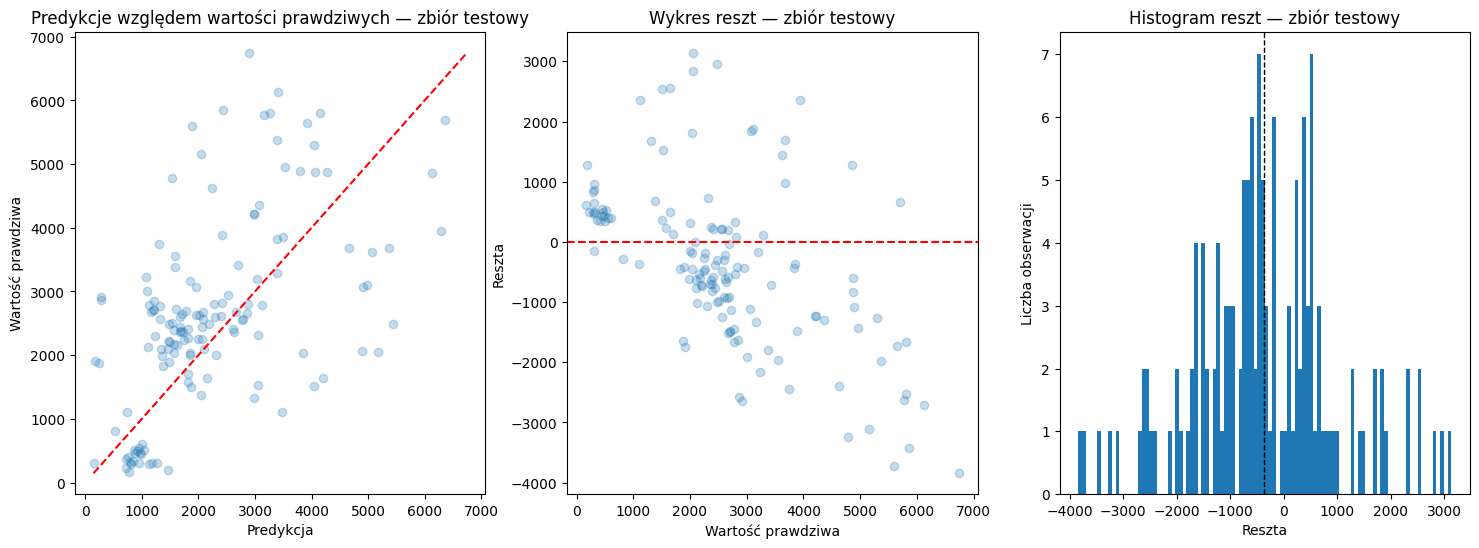

RMSE Test: 1387.34
Pomniejszony zysk: 1074788.00


In [47]:
model_evaluation(yhat=prediction_baseline, ytest=y_test)

Niestety, przez błędną prognozę, zysk naszego biznesu został pomniejszony o 1074788 zł w okresie od 1 stycznia 2020 roku do 20 stycznia 2020 roku.

# Drzewo decyzyjne

Zanim nauczymy model, to stwórzmy własny ‘scorer’, który postaramy się minimalizować naszymi modelami. Będzie on oparty o funkcję, która oblicza koszt powstały przez błędną prognozę.

In [48]:
cost_scorer = make_scorer(Cost, greater_is_better=False)

Pierwszy model, który stworzymy to proste drzewo decyzyjne. Jednak zgodnie ze sztuką analizy danych wybierzemy hiperparametry w oparciu o siatkę hiperparametrów na podzbiorach walidacyjnych. Dane, które wykorzystujemy to szeregi czasowe, zatem obserwacje są względem siebie zależne. Nie możemy stosować randomizacji przy podziale na zbiór treningowy/testowy, jak i nie możemy stosować walidacji krzyżowej (Cross-validation). W tej sytuacji dochodziłoby do wycieku danych. Dlatego w każdym z tych podziałów indeksy testowe, czy to walidacyjne, muszą być wyższe niż treningowe. Do podziału na zbiory walidacyjne stosujemy zatem TimeSeriesSplit.

In [49]:
tree = DecisionTreeRegressor(random_state=2022)  # Tworzy model drzewa decyzyjnego i zapewnia powtarzalność wyników.

params = {  # Definiuje hiperparametry sprawdzane podczas strojenia modelu.
    'max_depth': [2, 3, 5, 7, 10],  # Określa testowane maksymalne głębokości drzewa.
    'min_samples_leaf': [2, 3, 5, 7, 10]  # Określa minimalną liczbę obserwacji w liściu.
}

tree_gridsearch = GridSearchCV(  # Tworzy mechanizm przeszukujący wszystkie kombinacje hiperparametrów.
    estimator=tree,  # Przekazuje drzewo decyzyjne do optymalizacji.
    param_grid=params,  # Przekazuje zestaw testowanych hiperparametrów.
    scoring=cost_scorer,  # Ocenia modele za pomocą wcześniej przygotowanej funkcji kosztu.
    cv=TimeSeriesSplit(n_splits=5),  # Stosuje walidację krzyżową zachowującą kolejność czasową danych.
    verbose=10,  # Wyświetla szczegółowe informacje o postępie obliczeń.
    n_jobs=-1  # Wykorzystuje wszystkie dostępne rdzenie procesora.
)

tree_gridsearch.fit(X_train, y_train)  # Testuje kombinacje parametrów i dopasowuje najlepszy model do całego zbioru treningowego.

print(  # Wyświetla parametry najlepszego znalezionego modelu.
    '\nNajlepsze hiperparametry:',
    tree_gridsearch.best_params_
)

tree_model = tree_gridsearch.best_estimator_  # Zapisuje najlepsze dopasowane drzewo do zmiennej `tree_model`.

Fitting 5 folds for each of 25 candidates, totalling 125 fits

Najlepsze hiperparametry: {'max_depth': 5, 'min_samples_leaf': 3}


desc:

Kod testuje łącznie 25 kombinacji parametrów:

5 wartości max_depth × 5 wartości min_samples_leaf = 25 kombinacji

Każda kombinacja jest oceniana pięciokrotnie za pomocą TimeSeriesSplit, więc wykonywanych jest:
25 kombinacji × 5 podziałów = 125 dopasowań modelu

TimeSeriesSplit jest właściwy dla szeregu czasowego, ponieważ podczas walidacji model uczy się na wcześniejszych obserwacjach i jest oceniany na późniejszych.

Ważne: funkcja kosztu powinna być przekazana jako scorer minimalizowany przez GridSearchCV:

cost_scorer = make_scorer(Cost, greater_is_better=False)  # Informuje GridSearchCV, że mniejszy koszt oznacza lepszy model.

GridSearchCV standardowo wybiera największy wynik. greater_is_better=False zmienia znak kosztu, dzięki czemu najmniejszy rzeczywisty koszt zostanie uznany za najlepszy.

cd kurs

Wykonajmy teraz prognozę na zbiorze testowym, wykorzystując nauczony przed chwilą model drzewa decyzyjnego.

In [50]:
prediction_tree = tree_model.predict(X_test)  # Generuje prognozy dla cech ze zbioru testowego.

prediction_tree = pd.Series(  # Zamienia tablicę prognoz NumPy na serię Pandas.
    prediction_tree,  # Przekazuje wartości przewidziane przez model.
    index=y_test.index,  # Przypisuje prognozom daty odpowiadające wartościom rzeczywistym.
    name='DecisionTree_prediction'  # Nadaje serii czytelną nazwę.
)

prediction_tree  # Wyświetla prognozy drzewa decyzyjnego.

2020-01-01     195.750000
2020-01-02    1894.000000
2020-01-03    1894.000000
2020-01-04     203.852941
2020-01-05     203.852941
                 ...     
2020-05-16    3191.152941
2020-05-17    1642.702703
2020-05-18    2565.600000
2020-05-19    4135.896000
2020-05-20    5968.239130
Freq: D, Name: DecisionTree_prediction, Length: 141, dtype: float64

tree_model.predict(X_test) zwraca tablicę liczb bez indeksu dat. pd.Series(..., index=y_test.index) dodaje do prognoz daty ze zbioru testowego, co ułatwia porównanie ich z y_test, narysowanie wykresu oraz obliczenie kosztu.

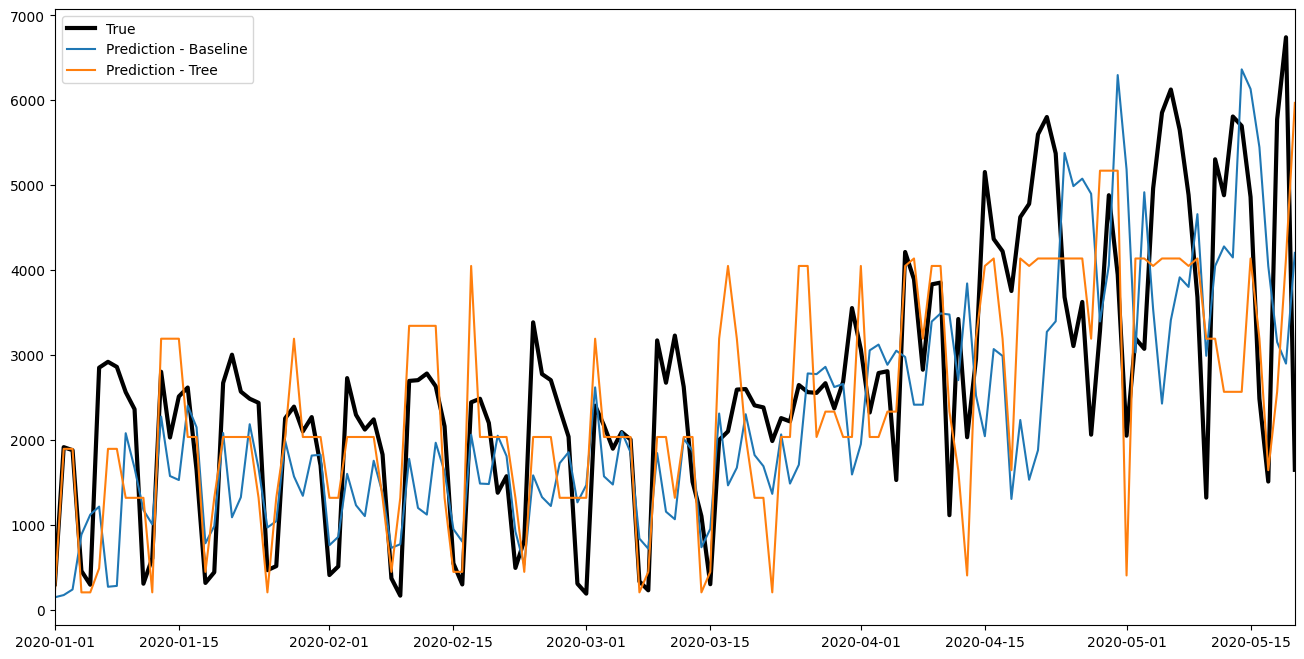

In [51]:
plot_prediction_vs_true(yhat_list=[prediction_baseline, prediction_tree],
                        yhat_names=['Baseline', 'Tree'],
                        ytest=y_test)

Forecast modelu baselinowego wygląda bardziej naturalnie, drzewo decyzyjne zgodnie ze swoją naturą dla problemu regresji tworzy ‘schodki’.

Jednak nie o wizualizację nam chodzi tylko o minimalizację kosztu, zatem jak to wygląda?

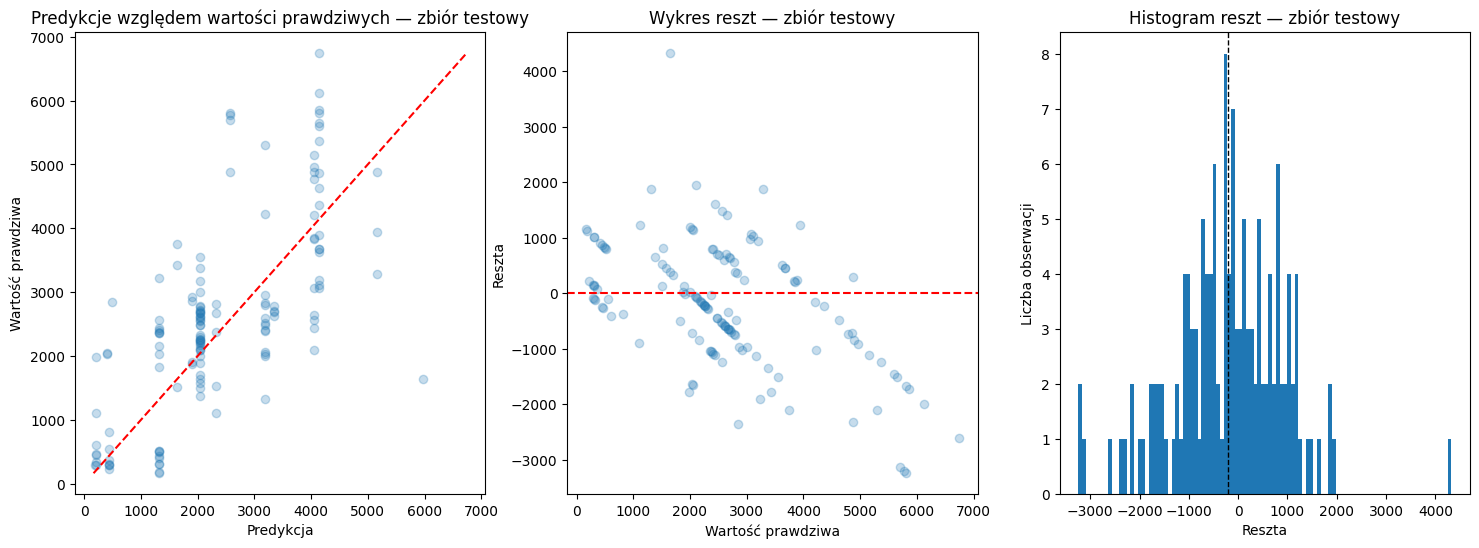

RMSE Test: 1132.88
Pomniejszony zysk: 800291.00


In [52]:
model_evaluation(yhat=prediction_tree, ytest=y_test)

WoW! Gdyby zarząd wcześniej zdecydował się na zastosowanie solidnej analizy danych, to w budżecie byłoby dodatkowe 80 000 zł!

# Random forest

Drzewo decyzyjne dało już lepsze rezultaty niż model podstawowy, teraz czas sprawdzić, jak sobie poradzi Random Forest. Siatka hiperparametrów będzie taka sama, zaś liczba estymatorów zostanie ustalona na 1000.

In [53]:
forest = RandomForestRegressor(  # Tworzy model lasu losowego.
    n_estimators=1000,  # Ustawia liczbę drzew w lesie na 1000.
    random_state=2022,  # Zapewnia powtarzalność wyników.
    n_jobs=-1  # Wykorzystuje wszystkie dostępne rdzenie procesora podczas trenowania drzew.
)

params = {  # Definiuje siatkę hiperparametrów do przetestowania.
    'max_depth': [2, 3, 5, 10],  # Określa testowane maksymalne głębokości drzew.
    'min_samples_leaf': [3, 5, 10, 15]  # Określa minimalną liczbę obserwacji w liściu.
}

forest_gridsearch = GridSearchCV(  # Tworzy mechanizm wyszukiwania najlepszych hiperparametrów.
    estimator=forest,  # Przekazuje model lasu losowego do optymalizacji.
    param_grid=params,  # Przekazuje zestaw testowanych hiperparametrów.
    scoring=cost_scorer,  # Ocenia modele za pomocą własnej funkcji kosztu.
    cv=TimeSeriesSplit(n_splits=5),  # Stosuje pięć podziałów zachowujących kolejność czasową.
    verbose=10,  # Wyświetla szczegółowe informacje o postępie obliczeń.
    n_jobs=-1  # Równolegle testuje różne kombinacje hiperparametrów.
)

forest_gridsearch.fit(X_train, y_train)  # Sprawdza wszystkie kombinacje i dopasowuje najlepszy model do całego zbioru treningowego.

print(  # Wyświetla najlepszą znalezioną kombinację parametrów.
    '\nNajlepsze hiperparametry:',
    forest_gridsearch.best_params_
)

forest_model = forest_gridsearch.best_estimator_  # Zapisuje najlepszy dopasowany model lasu losowego.

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Najlepsze hiperparametry: {'max_depth': 10, 'min_samples_leaf': 3}


desc:
Kod sprawdza 16 kombinacji hiperparametrów:
    
4 wartości max_depth × 4 wartości min_samples_leaf = 16 kombinacji

Przy pięciu podziałach czasowych daje to:
16 kombinacji × 5 podziałów = 80 dopasowań

Ponieważ każde dopasowanie buduje 1000 drzew, obliczenia mogą długo trwać. n_jobs=-1 występuje w dwóch miejscach:
w RandomForestRegressor — równolegle buduje drzewa,
w GridSearchCV — równolegle testuje modele.
    
Takie zagnieżdżone przetwarzanie równoległe może mocno obciążyć komputer. Bezpieczniejsza konfiguracja to pozostawienie równoległości tylko w GridSearchCV:
forest = RandomForestRegressor(
    n_estimators=1000,
    random_state=2022,
    n_jobs=1
)

Pamiętaj również, że scorer powinien minimalizować koszt:
cost_scorer = make_scorer(Cost, greater_is_better=False)  # Niższy koszt oznacza lepszy model.

Kolejność zapewne znasz już dobrze, teraz czas na wykonanie prognozy i następnie zwizualizowanie prognozy względem wartości prawdziwej oraz prognoz poprzednich modeli.

In [54]:
prediction_forest = forest_model.predict(X_test)
prediction_forest = pd.Series(prediction_forest, index=y_test.index)
prediction_forest

2020-01-01     485.757034
2020-01-02    1691.343647
2020-01-03    1719.033998
2020-01-04     204.484136
2020-01-05     194.685666
                 ...     
2020-05-16    3163.348159
2020-05-17    1692.580394
2020-05-18    4756.102553
2020-05-19    4817.829051
2020-05-20    5684.908053
Freq: D, Length: 141, dtype: float64

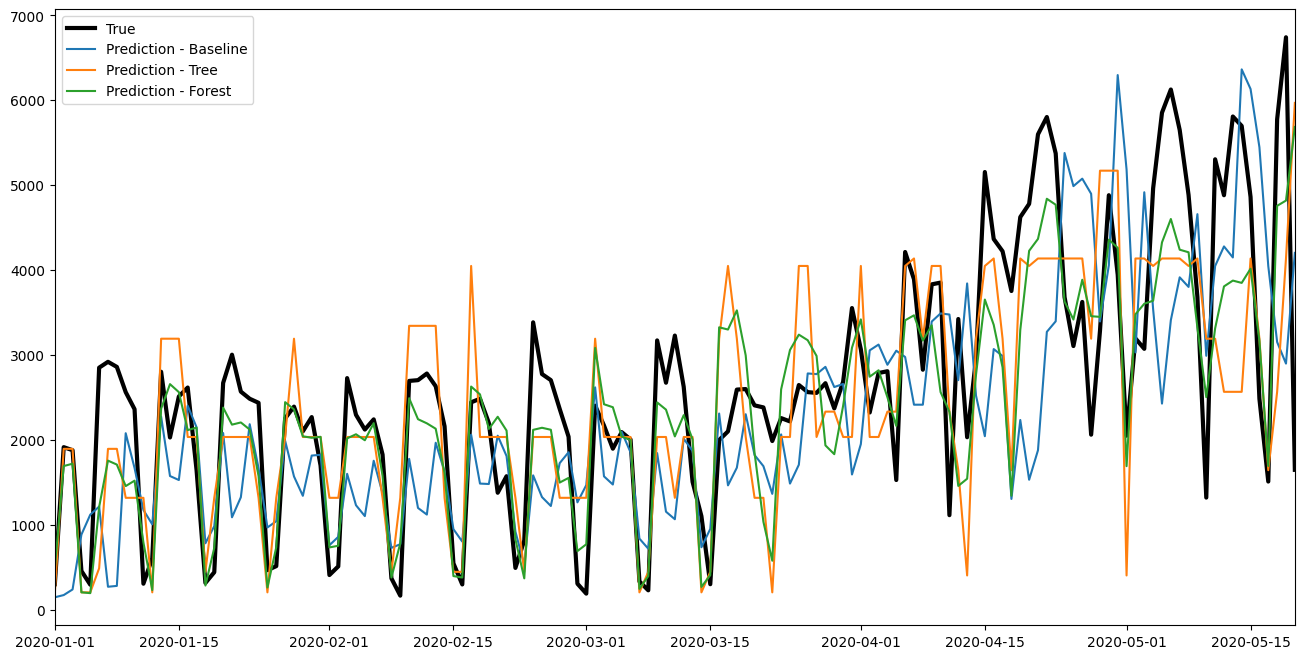

In [55]:
plot_prediction_vs_true(yhat_list=[prediction_baseline, prediction_tree, prediction_forest],
                        yhat_names=['Baseline', 'Tree', 'Forest'],
                        ytest=y_test)

Ten Forecast wygląda naprawdę dobrze, jednak każdy z modeli ma problem dla prognozy wartości od połowy kwietnia – wartoby zweryfikować dlaczego. Być może brakuje jakiejś informacji modelowi, która poprawiłaby jakość prognozy.

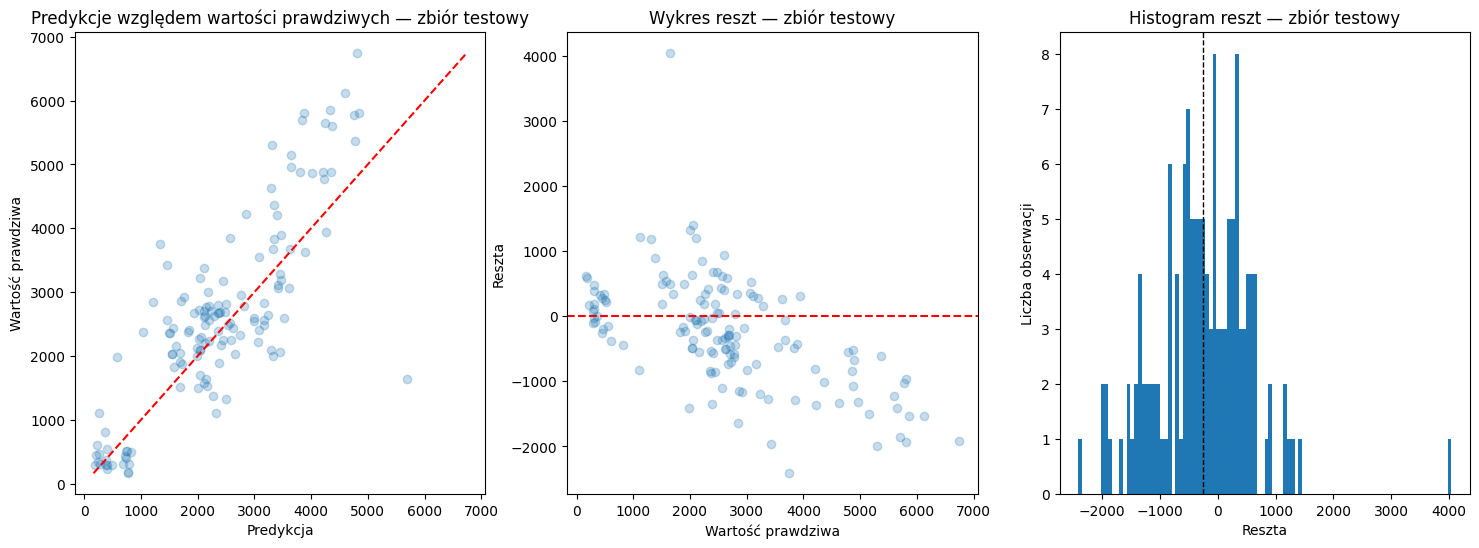

RMSE Test: 870.53
Pomniejszony zysk: 664038.00


In [56]:
model_evaluation(yhat=prediction_forest, ytest=y_test)

Patrząc na wyniki zapewne zarząd żałuje, że wcześniej nie zainwestował w takie rozwiązanie.

# Interpretacja modelu

Jest to temat, który wykracza poza zakres materiału, ale ważne by się z tym zapoznać. Wiemy, że nasz model potrafi robić prognozę, ale często chcielibyśmy zrozumieć, jaki wpływ mają zmienne na wartość końcowej prognozy. Do tego wykorzystamy wartości Shapleya, technikę zaczerpniętą z teorii gier. Jeśli chcesz dowiedzieć się więcej, możesz przeczytać ten rozdział.

In [57]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


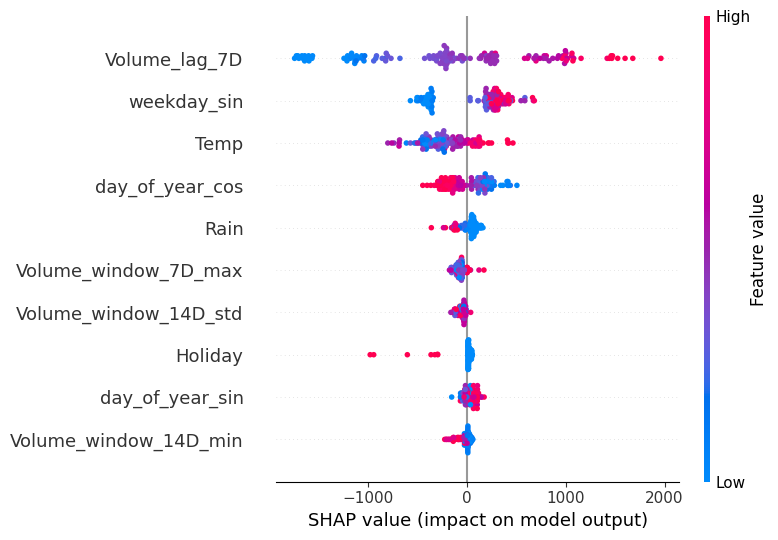

In [58]:
import shap
explainer = shap.TreeExplainer(forest_model)  # Tworzy obiekt SHAP przeznaczony do wyjaśniania modeli opartych na drzewach.

shap_values = explainer.shap_values(X_test)  # Oblicza wpływ każdej cechy na prognozę dla każdej obserwacji testowej.

shap.summary_plot(  # Tworzy zbiorczy wykres wpływu cech na prognozy modelu.
    shap_values,  # Przekazuje obliczone wartości SHAP.
    X_test  # Przekazuje wartości cech oraz ich nazwy.
)

Wykres SHAP pokazuje, jak poszczególne cechy wpływają na prognozowaną liczbę rowerów:
- cechy są uporządkowane od najważniejszej do najmniej ważnej,
- każdy punkt reprezentuje jedną obserwację ze zbioru testowego,
- położenie po prawej oznacza zwiększenie prognozy,
- położenie po lewej oznacza zmniejszenie prognozy,
- czerwony kolor oznacza wysoką wartość cechy,
- niebieski kolor oznacza niską wartość cechy.
  
Przykładowo, czerwone punkty po prawej stronie oznaczają, że wysokie wartości danej cechy zwykle zwiększają prognozowaną liczbę wypożyczeń.

X_test_sample = X_test.sample(n=min(500, len(X_test)), random_state=2022)  # Losuje maksymalnie 500 obserwacji.
shap_values = explainer.shap_values(X_test_sample)  # Oblicza wartości SHAP dla próbki.
shap.summary_plot(shap_values, X_test_sample)  # Wyświetla wykres dla próbki danych.

Spójrz na przykład na temperaturę, wyższe wartości mają dodatni wpływ na prognozę. Inaczej ma się to do deszczu, gdzie wyższe wartości mają negatywny wpływ na prognozę. W dodatku zauważyć możemy, że więszy wpływ na wartość końcową ma temperatura.

Jak czytać wykres:
- Każda kropka oznacza jeden dzień ze zbioru testowego.
- Kolor oznacza wartość cechy:czerwony/różowy — wysoka,
- niebieski — niska.

Pozycja pozioma oznacza wpływ na prognozę:
- prawa strona — zwiększenie prognozowanej liczby rowerów,
- lewa strona — zmniejszenie prognozy,
- okolice zera — niewielki wpływ.

Cechy są ułożone od najważniejszej do najmniej ważnej.
-Interpretacja najważniejszych cech
-Volume_lag_7D
 To zdecydowanie najważniejsza cecha.
 Wysoka liczba wypożyczeń sprzed 7 dni — czerwone punkty po prawej — zwiększa prognozę nawet o ponad 2000 rowerów.
 Niska liczba wypożyczeń sprzed 7 dni — niebieskie punkty po lewej — obniża prognozę.
 Model mocno zakłada, że wynik w danym dniu będzie podobny do wyniku z tego samego dnia poprzedniego tygodnia.
- weekday_sin
Jest to druga najważniejsza cecha, opisująca dzień tygodnia w sposób cykliczny.
Wyższe wartości tej zmiennej przeważnie zwiększają prognozę.
Niższe wartości najczęściej ją zmniejszają.
Nie należy jednak interpretować tego jako „wyższy dzień tygodnia”, ponieważ jest to wartość po transformacji sinusowej. Żeby sprawdzić dokładnie, które dni tygodnia zwiększają lub zmniejszają prognozę, lepszy będzie osobny wykres zależności SHAP.
- Temp
Opis dotyczący temperatury jest poprawny:
wyższa temperatura — czerwone punkty, głównie po prawej — zwiększa prognozę,
niższa temperatura — niebieskie punkty, głównie po lewej — zmniejsza prognozowaną liczbę wypożyczeń.
Wpływ temperatury jest zauważalny, ale znacznie mniejszy niż wpływ Volume_lag_7D.
day_of_year_cos
Ta cecha opisuje sezonowość roczną:
wysokie wartości są najczęściej po lewej, więc zmniejszają prognozę,
niskie wartości częściej znajdują się po prawej, więc zwiększają prognozę.
Ponieważ jest to cosinusowa transformacja dnia roku, nie można jej czytać bezpośrednio jako „późniejszy dzień roku”. W połączeniu z day_of_year_sin informuje model, w jakiej części roku znajduje się obserwacja.
Rain
Opis deszczu również jest zgodny z wykresem:
wysokie wartości opadów — czerwone punkty — występują głównie po lewej stronie i obniżają prognozę,
niskie wartości — niebieskie punkty — znajdują się bliżej zera lub lekko po prawej.
Deszcz ma jednak mniejszy wpływ niż temperatura, ponieważ:
Temp znajduje się wyżej na liście,
punkty dla Temp mają większy rozrzut na osi SHAP.
Holiday
To cecha binarna:
czerwone punkty oznaczają święto (Holiday = 1),
niebieskie punkty oznaczają zwykły dzień (Holiday = 0).
Święta wyraźnie zmniejszają prognozowaną liczbę wypożyczeń — niektóre czerwone punkty mają wartość SHAP mniejszą niż -1000. Zwykłe dni mają wpływ bliski zeru.
Pozostałe cechy
Volume_window_7D_max, Volume_window_14D_std i Volume_window_14D_min mają relatywnie małe znaczenie — ich punkty są skupione blisko zera. day_of_year_sin również ma mniejszy wpływ niż cosinusowa część sezonowości.
Najtrafniejszy opis wykresu brzmi:
Największy wpływ na prognozę ma liczba wypożyczeń sprzed siedmiu dni. Jej wysokie wartości zwiększają prognozę, a niskie ją zmniejszają. Wyższa temperatura również przeważnie zwiększa przewidywaną liczbę wypożyczeń, natomiast większe opady i dni świąteczne ją obniżają. Temperatura ma większe znaczenie dla modelu niż deszcz, ale mniejsze niż liczba wypożyczeń sprzed tygodnia i zakodowany dzień tygodnia.

Wartości SHAP są tutaj wyrażone w jednostkach prognozy. Przykładowo SHAP = +1000 oznacza, że dana cecha podniosła wynik modelu dla konkretnego dnia o około 1000 rowerów względem wartości bazowej. Wykres opisuje sposób działania modelu, ale sam nie dowodzi związku przyczynowego.

# 20.5  Wdrozenie

Wykorzystując bibliotekę joblib, możemy serializować modele i je zapisać. Taki model może być wykorzystany w aplikacji, dashbordzie, czy w systemie, który przesyła prognozę do wewnętrzego systemu firmy.

In [60]:
import joblib  # Importuje bibliotekę służącą m.in. do zapisywania modeli.

joblib.dump(
    forest_model,        # Wskazuje wytrenowany model, który ma zostać zapisany.
    'forest_model.pkl'   # Określa nazwę pliku z zapisanym modelem.
)

['forest_model.pkl']

desc:
Sam model nie wykonuje przygotowania danych. Przed wywołaniem predict() nowe dane muszą mieć dokładnie takie same kolumny, ich kolejność i sposób przygotowania jak X_train.
Najbezpieczniej zapisywać kompletny pipeline zawierający przygotowanie danych i model, jeżeli cały proces został zbudowany w formie jednego Pipeline.
Nie należy również otwierać plików .pkl lub joblib pochodzących z nieznanego źródła. Podczas joblib.load() taki plik może wykonać szkodliwy kod.